# 🐇 Build a Large Language Model From Scratch
## *The Wonderland Edition*

<a href="https://colab.research.google.com/github/pvergadia/llm-from-scratch-wonderland/blob/main/Build_an_LLM_From_Scratch_Wonderland.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a>

> *"Begin at the beginning," the King said, very gravely, "and go on till you come to the end: then stop."*
> — Lewis Carroll, *Alice's Adventures in Wonderland*

Welcome. Over the next few hours you are going to build a working **GPT-style large language model** with your own hands. Not "call an API." Not "fine-tune with three lines of a library." You will write the tokenizer, the attention mechanism, the transformer block, the training loop — **all of it** — in plain PyTorch.

By the end you will have:

| # | What you build | What it does |
|---|---|---|
| 1 | 🎲 **The Dumbest Language Model** | Predicts the next word from one word of memory. Fails hilariously — and shows you exactly what a real LLM must fix. |
| 2 | ✂️ **A tokenizer** | Turns text into numbers. Two versions: yours, then GPT-2's real one. |
| 3 | 👁️ **Attention** | The idea that made all of this work. Built from a dot product upward. |
| 4 | 🏗️ **A full GPT** | The real GPT-2 small architecture — 12 transformer blocks, layer norm, GELU, residual connections, 163M parameters. |
| 5 | 🎓 **WonderGPT** | Your own model, trained by you, on *Alice in Wonderland*. It will learn to write like Lewis Carroll. Badly. Then less badly. |
| 6 | 🔍 **A classifier** | "Wonderland or Baker Street?" — fine-tune the model to tell Lewis Carroll from Arthur Conan Doyle. |
| 7 | 🐈 **Cheshire** | An instruction-following assistant. The same trick that turned GPT-3 into ChatGPT, at miniature scale. |

---

### How to read this notebook

Run every cell in order, top to bottom. Each **step** ends with a `🎯 Your turn` box — small experiments that are where the real learning happens. Skipping them is like reading about swimming.

**You do not need to know PyTorch.** Every code cell starts with a plain-English note on what it does, every tensor is labelled with its shape, and each PyTorch trick is explained the first time it appears. If a line looks like magic, there is a comment on it.

**A promise:** nothing here is magic. Every single line is arithmetic you already know — multiply, add, average, compare. The astonishing part is not any individual step. It is that the steps, stacked deep enough and fed enough text, start to *talk back*.

*Based on the book [Build a Large Language Model (From Scratch)](https://www.manning.com/books/build-a-large-language-model-from-scratch) by Sebastian Raschka, chapters 1–7, restaged with new examples and a new cast.*

---
## Step 0 · Setup

### The one-sentence version of everything

> **A large language model is a machine that reads some text and guesses what comes next. That's it. Everything else is engineering.**

Hold on to that sentence. When the math gets thick in Step 3, come back to it. Attention, layer norm, multi-head, residual streams — every one of them exists for a single purpose: to make the next-word guess *less wrong*.

Here is the entire pipeline you are about to build, in one picture. Six boxes. You will write all six.

<p style="text-align:center">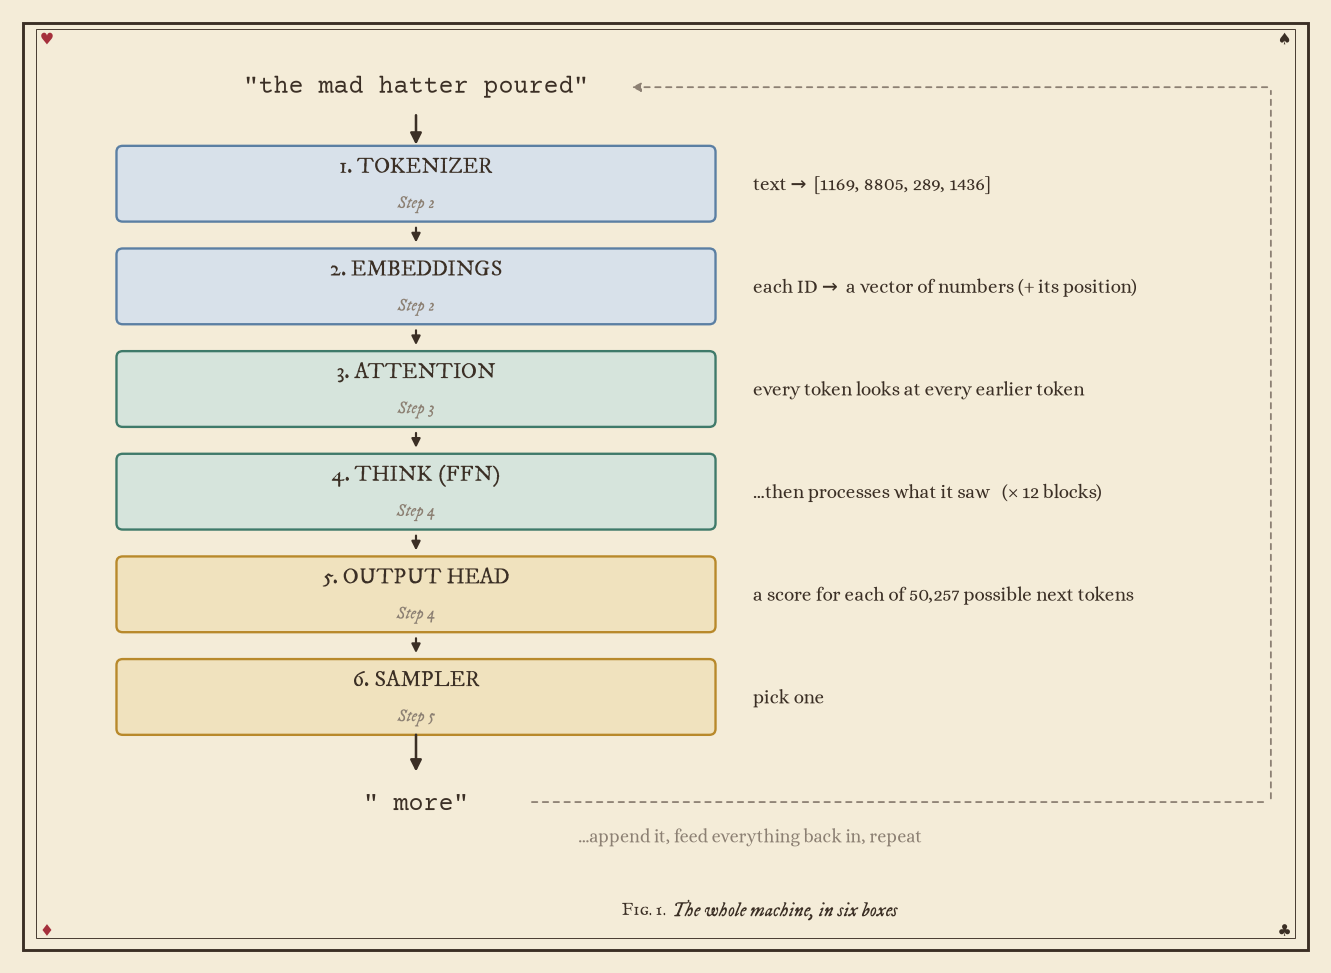</p>

### ⚡ Running this on Google Colab

**Turn the GPU on first.** `Runtime → Change runtime type → T4 GPU`, then `Save`.

Everything here runs on CPU too, but Steps 5–7 go from minutes to the better part of an hour. Check the device printout two cells down — if it says `cuda`, you're set.

Colab already has PyTorch and matplotlib; the cell below just adds `tiktoken`.

> 💾 **Colab files are temporary.** The books and model checkpoints this notebook writes vanish when the runtime disconnects. That's fine — everything is re-downloadable. If you want to keep your trained models, mount Drive (`from google.colab import drive; drive.mount('/content/drive')`) and save into `/content/drive/MyDrive/`.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Installs the one library Colab doesn't ship with (tiktoken = GPT-2's tokenizer),
# then prints the version of each library so you know what you're running.
# The "%pip" at the start is a Jupyter/Colab command, not Python — it runs pip
# inside this notebook's environment.

%pip install -q tiktoken

from importlib.metadata import version     # a tiny helper that reads a package's version string

for pkg in ["torch", "tiktoken", "matplotlib"]:
    try:
        print(f"{pkg:<12} {version(pkg)}")   # {pkg:<12} = left-align in a 12-character column
    except Exception:
        print(f"{pkg:<12} ❌ NOT INSTALLED  ->  pip install {pkg}")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# 1. Imports PyTorch, the library that does all the math for us.
# 2. Picks the fastest hardware available (GPU if you have one, else CPU).
# 3. Sets a FAST switch you can flip to trade quality for speed.
# 4. Defines free(), a tiny cleanup helper we'll call after finishing with big models.

import torch      # PyTorch: tensors (multi-dimensional arrays) + automatic gradients + GPU support


def pick_device():
    """Return the best place to run our math: 'cuda' (NVIDIA GPU), 'mps' (Apple GPU), or 'cpu'."""
    if torch.cuda.is_available():                    # is there an NVIDIA GPU? (Colab T4 -> yes)
        return torch.device("cuda")
    if torch.backends.mps.is_available():            # Apple Silicon GPU?
        major, minor = map(int, torch.__version__.split(".")[:2])
        if (major, minor) >= (2, 9):                 # older MPS builds have numerical quirks
            return torch.device("mps")
    return torch.device("cpu")                       # always works, just slower


device = pick_device()
print("Running on:", device)
if device.type == "cpu":
    print("  ⚠️  No GPU found. Everything still works, but Steps 5-7 will be slow.")
    print("     On Colab: Runtime -> Change runtime type -> T4 GPU.")


# ── Speed dial ──────────────────────────────────────────────────────────────
# FAST = True  -> shorter training runs. Great for a first pass or a live demo.
# FAST = False -> the real thing. Better results, longer waits.
FAST = True
print(f"FAST mode: {FAST}  (flip this at the top of Step 0 to change it)")


# ── Housekeeping ────────────────────────────────────────────────────────────
# LLMs are memory hogs. When we're done with a model we `del` it and call free()
# so the next step has room. (Python's garbage collector is lazy; this nudges it.)
import gc

def free():
    """Run after `del some_model` to actually reclaim the memory."""
    gc.collect()                                     # Python: release unreferenced objects
    if device.type == "cuda":
        torch.cuda.empty_cache()                     # GPU: hand cached memory back
    elif device.type == "mps":
        torch.mps.empty_cache()

print("\n💾 Each 124M-parameter model here is ~650 MB, and training needs several times")
print("   that. We free models as we finish with them so the later steps have room.")

### 📎 PyTorch in twelve lines

Everything in this notebook is built from a handful of tensor operations. Skim this now; come back whenever a line of code looks strange. Every one of these shows up again with a comment at the point of use.

In [ ]:
# ── A pocket reference. Run it, read the output, move on. ───────────────────
t = torch.tensor([[1., 2., 3.],
                  [4., 5., 6.]])                     # a 2-D tensor: 2 rows x 3 columns

print("shape        ", t.shape)                     # torch.Size([2, 3])  <- rows, columns
print("t[1]         ", t[1])                        # indexing: the second row (Python counts from 0)
print("t[:, 0]      ", t[:, 0])                     # ':' means 'all rows'; ', 0' picks column 0
print("t.T          ", t.T.shape)                   # transpose: swap rows and columns -> (3, 2)
print("t @ t.T      ", (t @ t.T).shape)             # '@' is matrix multiplication -> (2, 2)
print("t * 2        ", (t * 2)[0])                  # '*' is element-wise (each number separately)
print("sum(dim=-1)  ", t.sum(dim=-1))               # dim=-1 = 'along the LAST axis' -> one sum per row
print("keepdim      ", t.sum(dim=-1, keepdim=True).shape)  # keep the axis so shapes still line up: (2, 1)
print("softmax      ", torch.softmax(t, dim=-1)[0]) # turn a row of scores into probabilities that sum to 1
print("argmax       ", t.argmax(dim=-1))            # index of the biggest value in each row
print("view         ", t.view(3, 2).shape)          # reshape without copying (same 6 numbers, new grid)
print("item()       ", t[0, 0].item())              # pull a single number out as a plain Python float

# Two more ideas you'll meet:
#   torch.no_grad()  -> "don't track gradients here" (faster; used when we're only predicting, not learning)
#   .to(device)      -> move a tensor or model onto the GPU

### 📚 Our text: two very different books

Every language model is a mirror of what it read. We are going to feed ours two public-domain classics that could not be less alike:

| | Book | Vibe |
|---|---|---|
| 🐇 | *Alice's Adventures in Wonderland* — Lewis Carroll, 1865 | dream logic, talking animals, unhinged tea |
| 🔎 | *The Adventures of Sherlock Holmes* — Arthur Conan Doyle, 1892 | fog, deduction, cigar ash taxonomy |

*Alice* is our main training text (Steps 1–5). In Step 6 we bring in *Sherlock* and teach the model to tell the two authors apart.

Why *Alice*? Partly because it is short, free, and famous. Mostly because when a half-trained model produces beautiful nonsense — and it will — nonsense is exactly the house style.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Downloads both books from Project Gutenberg (once; they're cached on disk),
# strips the legal boilerplate and table of contents, and keeps the story text.
# At the end, `alice` is one long Python string holding the whole novel.

import os                      # files and paths
import re                      # regular expressions: pattern matching in text
import urllib.request          # downloading from a URL

BOOKS = {
    "alice":    ("https://www.gutenberg.org/files/11/11-0.txt",     "alice.txt"),
    "sherlock": ("https://www.gutenberg.org/files/1661/1661-0.txt", "sherlock.txt"),
}

def download(url, path):
    """Fetch a file once and cache it on disk. Skips the download if the file exists."""
    if os.path.exists(path):
        return
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})   # some sites refuse bare requests
    with urllib.request.urlopen(req, timeout=60) as r, open(path, "wb") as f:
        f.write(r.read())
    print(f"downloaded -> {path}")

def strip_gutenberg(raw):
    """Cut away the Project Gutenberg legal text, keep only the story."""
    # The story sits between two marker lines. re.S lets '.' match across line breaks,
    # because some books wrap the marker onto two lines.
    start = re.search(r"\*\*\* START OF (THE|THIS) PROJECT GUTENBERG.*?\*\*\*", raw, re.S)
    end   = re.search(r"\*\*\* END OF (THE|THIS) PROJECT GUTENBERG.*?\*\*\*",   raw, re.S)
    body = raw[start.end():end.start()] if (start and end) else raw
    body = body.replace("\r\n", "\n")                        # Windows line endings -> Unix
    body = re.sub(r"\n{3,}", "\n\n", body)                   # squash runs of blank lines
    # drop table-of-contents lines: indented, like "  IV.  Title" or " CHAPTER I.  Title"
    body = re.sub(r"^[ \t]+((CHAPTER\s+)?[IVXL]+\.)[ \t]+\S.*$\n?", "", body, flags=re.M)
    return re.sub(r"\n{3,}", "\n\n", body).strip()

texts = {}
for name, (url, path) in BOOKS.items():
    download(url, path)
    with open(path, "r", encoding="utf-8") as f:
        texts[name] = strip_gutenberg(f.read())
    print(f"{name:<9} {len(texts[name]):>7,} characters")    # {:>7,} = right-align, thousands separators

alice = texts["alice"]        # the string we'll use for most of the notebook
print("\n--- first 350 characters of our training text ---\n")
print(alice[:350])            # [:350] = the first 350 characters (string slicing)

---
# 🎲 Step 1 · The Dumbest Language Model in the World
### *(Chapter 1: what an LLM actually is)*

Before we build something impressive, let's build something **terrible** — on purpose. It takes ten lines, it runs instantly, and it will teach you more about why transformers exist than any diagram.

**The rules of the game.** Read all of *Alice*. For every word, write down which words came after it. To generate text: look at the last word, and roll a weighted die over the words that followed it in the book.

That's it. That is a real (if ancient) language model — a *bigram* model. It has exactly **one word of memory**.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# "Trains" the bigram model: for every word in the book, count which words came
# right after it. The whole model is one dictionary of counters.

import random
from collections import defaultdict, Counter
# Counter    = a dict that counts things:  Counter("aab") -> {'a': 2, 'b': 1}
# defaultdict = a dict that creates a missing key on first touch instead of erroring

# Chop the book into lowercase words (letters and apostrophes only; punctuation is dropped)
words = re.findall(r"[a-zA-Z']+", alice.lower())
print(f"{len(words):,} words in Wonderland\n")

# follows["alice"] will be a Counter of every word that ever came after "alice"
follows = defaultdict(Counter)
for current_word, next_word in zip(words, words[1:]):   # zip pairs each word with the one after it
    follows[current_word][next_word] += 1

# Peek at what the model "knows"
for w in ["alice", "queen", "very", "tea"]:
    top = ", ".join(f"{nxt} ({n})" for nxt, n in follows[w].most_common(5))
    print(f"after '{w}':  {top}")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Generates text: start from a word, look up what followed it in the book,
# pick one at random (weighted by how often it appeared), repeat.

def dumb_generate(seed_word, n_words=40, seed=7):
    """Roll a weighted die over 'what came next in the book', one word at a time."""
    rng = random.Random(seed)              # a seeded random generator, so results are repeatable
    out = [seed_word]
    for _ in range(n_words):
        options = follows[out[-1]]         # out[-1] = the LAST word generated so far (all we look at!)
        if not options:                    # dead end (a word that only ever ended the book) -> restart
            out.append(rng.choice(words))
            continue
        candidates  = list(options.keys())     # the possible next words
        frequencies = list(options.values())   # how often each one followed
        out.append(rng.choices(candidates, weights=frequencies)[0])   # weighted random pick
    return " ".join(out)

print("🎲 THE DUMBEST LANGUAGE MODEL SAYS:\n")
print(dumb_generate("alice"))
print()
print(dumb_generate("the", seed=99))

### What just happened

Look closely at that output. Two things are true at once:

✅ **It is not random.** "alice was" is plausible. "the queen" is plausible. Local pairs of words genuinely sound like English, because they *were* English.

❌ **It has no idea what it is saying.** The sentence falls apart after about four words. It forgets its own subject. It cannot close a quotation mark it opened. It will happily write *"the King of the King of the King."*

**Why?** Because the model's entire memory is **one word**. When it is choosing the word after `"said"`, it does not know whether the sentence started with *Alice* or the *Mad Hatter*. All the context has evaporated.

<p style="text-align:center">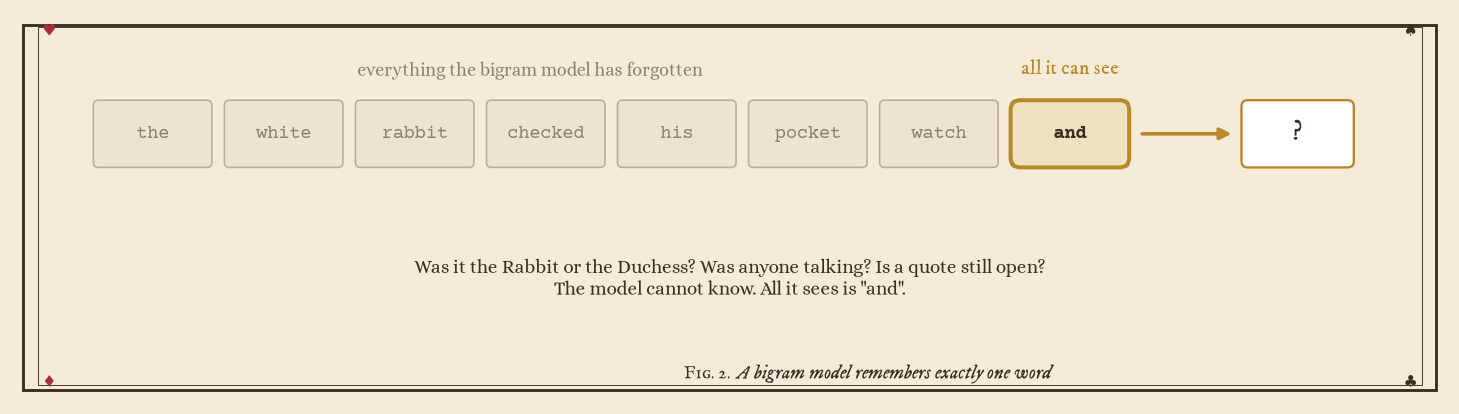</p>

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Shows the failure in slow motion: two contexts that differ completely but end in
# the same word get the SAME continuation, because the model only sees that word.

context_a = "the white rabbit checked his pocket watch and"
context_b = "the duchess threw the baby at alice and"

print("Context A:", context_a)
print("Context B:", context_b)
print("\nBoth end in the word 'and'. So the dumb model's prediction is the same:\n")

# .split(" ", 1)[1] drops the seed word "and" from the front of the generated text
print("A ->", context_a, "|", dumb_generate("and", 8, seed=3).split(" ", 1)[1])
print("B ->", context_b, "|", dumb_generate("and", 8, seed=3).split(" ", 1)[1])

print("\n💡 Identical continuations. The model threw away everything that mattered.")

### The whole rest of this notebook, in one line

> **How do we let the model look at *all* of the previous words — and decide, on its own, which ones matter?**

The 2017 answer to that question is called **attention**, and it is Step 3. Everything between here and there is plumbing: turning text into numbers the model can do arithmetic on.

---
### 🎯 Your turn (Step 1)
1. Build a **trigram** model: key `follows` on *pairs* of words instead of one word. Does the output get better? How much further can this trick take you?
2. Try seeding with a rare word like `"mock"` or `"caucus"`. What happens when a word has only one possible successor?
3. **Think:** a bigram model over 50,257 tokens needs a table of 50,257 × 50,257 numbers ≈ 2.5 billion entries — larger than GPT-2 — and it *still* only remembers one token. Scaling the dumb idea does not work. We need a different idea.

---
# ✂️ Step 2 · Turning Words Into Numbers
### *(Chapter 2: tokenization, embeddings, and the sliding window)*

Neural networks cannot read. They multiply matrices. So before anything else, we need a **reversible** way to turn `"Curiouser and curiouser!"` into a list of numbers — and back again.

This happens in three moves:

<p style="text-align:center">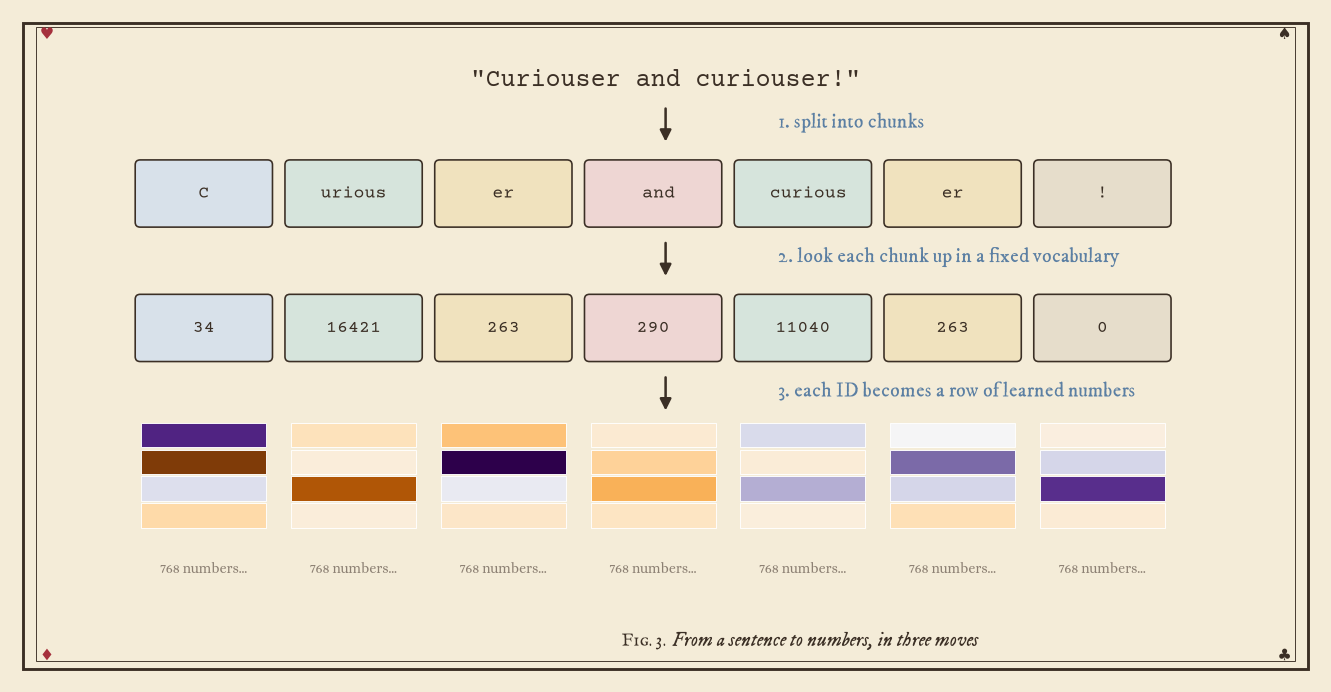</p>

Step ③ is the interesting one: those vectors are **not** assigned by us. They are learned during training, and they end up encoding *meaning*. We'll prove that at the end of Step 5.

## 2.1 · A tokenizer you write yourself

Start with the obvious approach: split on spaces and punctuation.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Three attempts at splitting a sentence into tokens, each a little smarter.
# re.split(pattern, text) cuts the text wherever the pattern matches. Wrapping the
# pattern in (...) keeps the separators in the output instead of throwing them away.

import re

sample = "Curiouser and curiouser! -- said Alice, who was much surprised."

# Attempt 1: split on whitespace only.  \s = any whitespace character
print("split on spaces:      ", re.split(r"(\s)", sample)[:12])

# Attempt 2: also split off commas and periods.  [,.] = a comma OR a period
print("...and , and .:       ", [t for t in re.split(r"([,.]|\s)", sample) if t.strip()][:12])

# Attempt 3: the full punctuation set (this is the one we keep)
#   [,.:;?_!"()\']  any one of these characters
#   |--             or a double dash
#   |\s             or whitespace
SPLIT_PATTERN = r'([,.:;?_!"()\']|--|\s)'
tokens = [t.strip() for t in re.split(SPLIT_PATTERN, sample) if t.strip()]   # .strip() drops empty/space-only bits
print("full punctuation:     ", tokens)

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Applies the splitter to the WHOLE book, then builds a vocabulary: every distinct
# token gets an integer ID. sorted(set(...)) = unique tokens, in alphabetical order.

preprocessed = [t.strip() for t in re.split(SPLIT_PATTERN, alice) if t.strip()]

all_words = sorted(set(preprocessed))                         # unique tokens, alphabetical
vocab     = {token: idx for idx, token in enumerate(all_words)}   # {"!": 0, '"': 1, ..., "zigzag": 3341}

print(f"{len(preprocessed):,} tokens in the book")
print(f"{len(vocab):,} unique tokens -> that's our vocabulary size\n")

print("A few entries from the middle of the vocabulary:")
for token, idx in list(vocab.items())[1200:1210]:
    print(f"  {idx:>5}  {token!r}")                              # !r shows quotes so you can see spaces

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Wraps the vocabulary in a class with two methods:
#   encode(text) -> list of integer IDs        (what the model consumes)
#   decode(ids)  -> text                       (what we read back)
# "class" bundles data (the two lookup tables) with the functions that use them.

class SimpleTokenizerV1:
    """Text <-> token IDs, using a fixed word-level vocabulary."""

    def __init__(self, vocab):                       # __init__ runs once when you create the object
        self.str_to_int = vocab                                   # "Alice" -> 19
        self.int_to_str = {i: s for s, i in vocab.items()}        # 19 -> "Alice"  (the reverse map)

    def encode(self, text):
        tokens = [t.strip() for t in re.split(SPLIT_PATTERN, text) if t.strip()]
        return [self.str_to_int[t] for t in tokens]               # look each token up

    def decode(self, ids):
        text = " ".join(self.int_to_str[i] for i in ids)          # IDs -> tokens, joined by spaces
        return re.sub(r'\s+([,.:;?!"()\'])', r"\1", text)         # remove the space before punctuation


tokenizer = SimpleTokenizerV1(vocab)

phrase = "Alice was beginning to get very tired of sitting by her sister."
ids = tokenizer.encode(phrase)
print("encoded:", ids)
print("decoded:", tokenizer.decode(ids))

### The trap

Our vocabulary was built from *Alice*. So what happens when a word from outside Wonderland shows up?

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Deliberately breaks the tokenizer. try/except catches the error so the notebook
# keeps going and we can read the message instead of crashing.

try:
    tokenizer.encode("Alice ordered a pizza")
except KeyError as e:                                # KeyError = "that key isn't in the dictionary"
    print(f"💥 KeyError: {e}")
    print("\n'pizza' does not appear in Alice in Wonderland, so it has no ID.")
    print("A tokenizer that crashes on unfamiliar words is not going to survive the internet.")

### Patch #1: special tokens

The traditional fix is to reserve a few **special tokens** with reserved meanings:

- `<|unk|>` — stand-in for any word not in the vocabulary
- `<|endoftext|>` — boundary between two unrelated documents
- `[BOS]` / `[EOS]` — beginning / end of a sequence (used by some models)
- `[PAD]` — filler so that batched sequences line up

GPT-2 only bothers with `<|endoftext|>` — for a reason we'll see in a moment.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Adds two special tokens to the END of the vocabulary and makes a V2 tokenizer that
# swaps any unknown word for <|unk|> instead of crashing.
# "class SimpleTokenizerV2(SimpleTokenizerV1)" = inherit everything from V1, then
# override just the encode() method.

all_tokens = sorted(set(preprocessed)) + ["<|endoftext|>", "<|unk|>"]
vocab_v2   = {token: idx for idx, token in enumerate(all_tokens)}


class SimpleTokenizerV2(SimpleTokenizerV1):
    """Same as V1, but unknown words become <|unk|> instead of an exception."""

    def encode(self, text):
        tokens = [t.strip() for t in re.split(SPLIT_PATTERN, text) if t.strip()]
        tokens = [t if t in self.str_to_int else "<|unk|>" for t in tokens]   # the one new line
        return [self.str_to_int[t] for t in tokens]


tokenizer_v2 = SimpleTokenizerV2(vocab_v2)

text = "Alice ordered a pizza <|endoftext|> The Cheshire Cat approved."
print("in : ", text)
print("ids: ", tokenizer_v2.encode(text))
print("out: ", tokenizer_v2.decode(tokenizer_v2.encode(text)))
print("\n😬 Every word outside Wonderland collapses into the same <|unk|> mush.")
print("   The model can never learn anything about them. We need something smarter.")

## 2.2 · Byte-pair encoding: the real trick

GPT-2's tokenizer never says "unknown." Its move is beautifully simple:

> **If you don't recognise the word, break it into pieces you *do* recognise. Keep breaking until you're down to single bytes if you have to.**

This is **byte-pair encoding (BPE)**. The vocabulary of 50,257 entries holds common whole words (` the`, ` Alice`), common fragments (`ing`, `un`, `er`), and — as a last resort — every individual byte. Nothing is unrepresentable. Ever.

The rules inside it were *learned* from data: start with single characters, then repeatedly merge whichever adjacent pair is most frequent, 50,000 times.

<p style="text-align:center">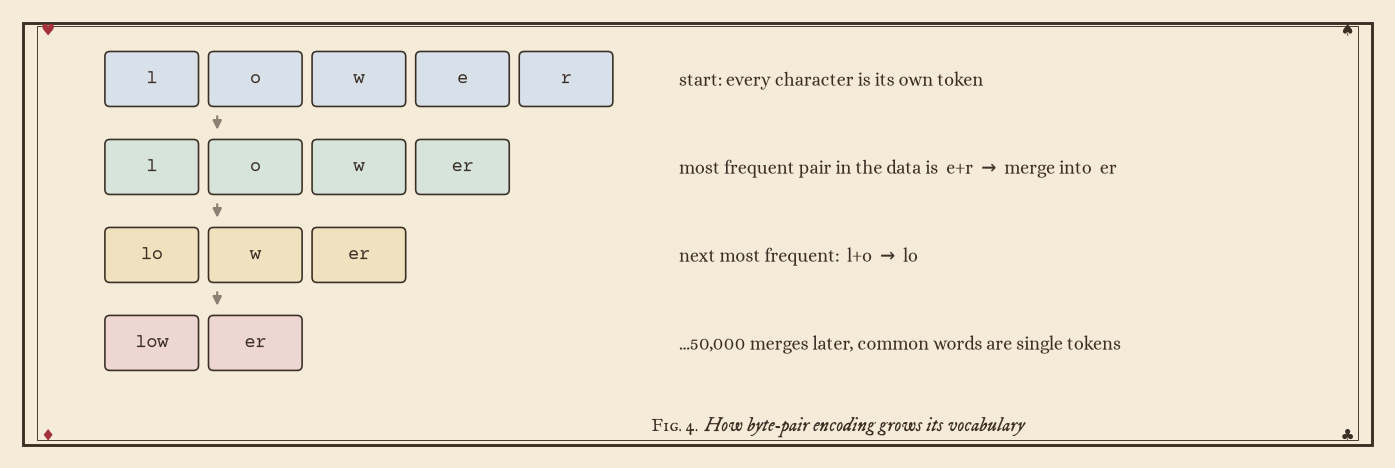</p>

We'll use OpenAI's own implementation via `tiktoken`. To make the splits visible, we'll paint each token a different colour.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Loads GPT-2's real BPE tokenizer and defines show_tokens(), which prints a
# sentence with each token painted a different colour (via a little HTML), so you
# can SEE where the cuts fall. Then tries it on some awkward inputs.

import tiktoken
from IPython.display import HTML, display        # lets a cell draw HTML instead of plain text

bpe = tiktoken.get_encoding("gpt2")              # the actual GPT-2 tokenizer (50,257 tokens)
print("vocabulary size:", bpe.n_vocab)

PALETTE = ["#D8E1EA", "#D6E4DC", "#F0E2BE", "#EED6D3", "#E6DDCB", "#E3D9EC"]   # pinafore, mushroom, key, hearts

def show_tokens(text, tok=bpe):
    """Draw a string with one coloured box per token, plus the IDs underneath."""
    ids = tok.encode(text, allowed_special={"<|endoftext|>"})   # allow the special token if present
    pieces = [tok.decode([i]) for i in ids]                     # decode each ID on its own
    boxes = "".join(
        f'<span style="background:{PALETTE[i % len(PALETTE)]};padding:3px 5px;margin:1px;'
        f'border-radius:4px;font-family:monospace;white-space:pre">{p}</span>'
        for i, p in enumerate(pieces))
    ids_html = " ".join(f'<span style="color:#888;font-family:monospace;font-size:0.85em">{i}</span>' for i in ids)
    display(HTML(f'<div style="margin:6px 0"><div>{boxes}</div><div>{ids_html}'
                 f' &nbsp;<b style="color:#A5303C">→ {len(ids)} tokens</b></div></div>'))

show_tokens("Alice ordered a pizza.")
show_tokens("The Jabberwocky galumphed back, chortling.")
show_tokens("antidisestablishmentarianism")
show_tokens("Wonderland 🐇 is 100% mad")

Notice what BPE did:

- Common words are **one token**: ` Alice`, ` pizza`, ` back`.
- Invented words get **shredded into readable parts**: `Jab | ber | w | ocky`, `gal | umph | ed`. The model has never seen "galumphed," but it *has* seen `ed` a million times — so it knows a verb in the past tense when it sees one.
- Even an emoji survives, as a handful of raw bytes (shown as �, because a single byte of a multi-byte character isn't printable on its own).

**Rule of thumb: 1 token ≈ 4 characters ≈ ¾ of an English word.** This is why API pricing is quoted per token, and why models have "context windows" measured in tokens.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Three famous tokenizer blind spots. Every one of these is a real limitation you
# will see in production models.

show_tokens("strawberry")           # 3 tokens, and none of them is a letter
show_tokens("  double  spaces")     # whitespace is part of the token
show_tokens("1234567890")           # numbers split in strange, inconsistent places

print("💡 A model that sees 'st | raw | berry' has to work surprisingly hard")
print("   to count the letter r. Many 'AI can't do X' puzzles are tokenizer puzzles.")

## 2.3 · The training data: a sliding window

Here is the sleight of hand that makes LLM training possible without a single human label.

We want the model to predict the next token. So we take the book, slide a window of `N` tokens across it, and for every window we say: **the input is these N tokens, the correct answer is the same N tokens shifted one step right.**

<p style="text-align:center">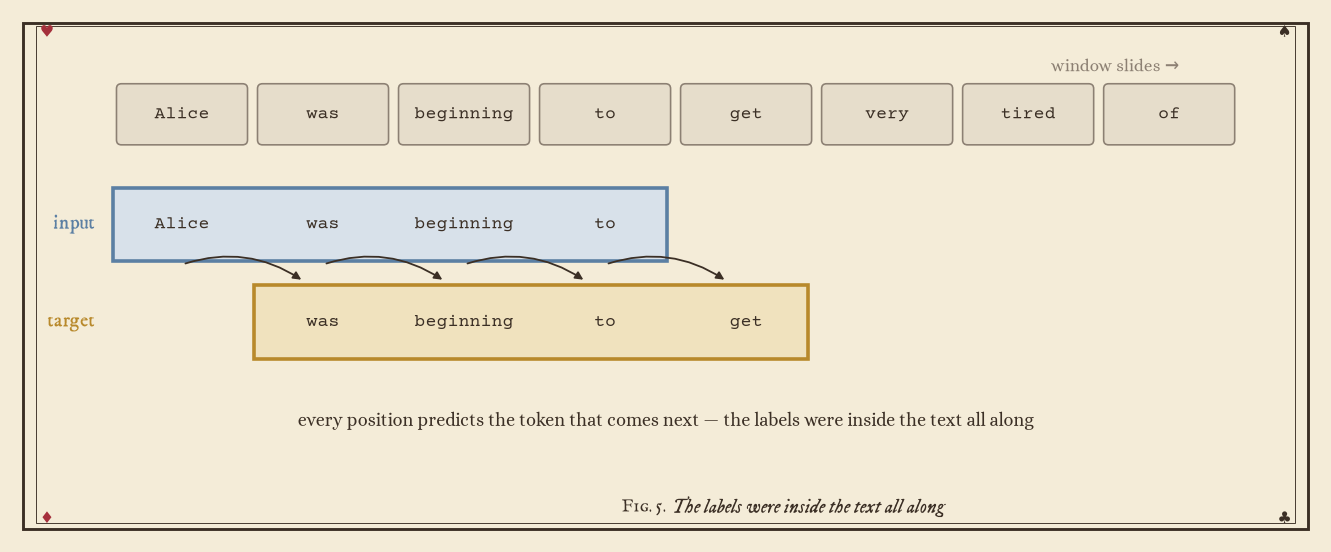</p>

The labels were inside the text the whole time. This is why it's called **self-supervised** learning, and it's why the internet — with no annotation whatsoever — became training data.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Tokenizes the whole book with BPE, then shows the "predict the next token" game
# one step at a time on a short slice.

enc_text = bpe.encode(alice)                     # the whole novel as a list of integers
print(f"Alice in Wonderland = {len(enc_text):,} GPT-2 tokens\n")

sample_ids = enc_text[50:]                       # skip the title page; start 50 tokens in
context_size = 4                                 # how many tokens the model gets to see

for i in range(1, context_size + 1):
    context = sample_ids[:i]                     # the first i tokens...
    target  = sample_ids[i]                      # ...and the one that comes right after
    print(f"{bpe.decode(context)!r:<45} ---> {bpe.decode([target])!r}")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Builds a PyTorch Dataset (a list of (input, target) pairs) and a DataLoader
# (something that hands them out in shuffled batches). These two classes are how
# ALL PyTorch training code feeds data to a model.

from torch.utils.data import Dataset, DataLoader


class GPTDataset(Dataset):
    """Slide a window over the text; each item is (input_chunk, target_chunk)."""

    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids, self.target_ids = [], []
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
        assert len(token_ids) > max_length, "text is shorter than the context window"

        # range(start, stop, step): i jumps forward by `stride` each time
        for i in range(0, len(token_ids) - max_length, stride):
            self.input_ids.append(torch.tensor(token_ids[i:i + max_length]))            # shape (max_length,)
            self.target_ids.append(torch.tensor(token_ids[i + 1:i + max_length + 1]))   # same, shifted by 1

    def __len__(self):                               # how many windows? (DataLoader asks this)
        return len(self.input_ids)

    def __getitem__(self, idx):                      # give me window number idx
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader(txt, batch_size=4, max_length=256, stride=128,
                      shuffle=True, drop_last=True, num_workers=0):
    dataset = GPTDataset(txt, tiktoken.get_encoding("gpt2"), max_length, stride)
    return DataLoader(dataset,
                      batch_size=batch_size,     # how many windows per batch
                      shuffle=shuffle,           # random order each epoch (good for training)
                      drop_last=drop_last,       # throw away a final half-size batch
                      num_workers=num_workers)


# stride == max_length means the windows tile the text with no overlap
loader = create_dataloader(alice, batch_size=4, max_length=8, stride=8, shuffle=False)
inputs, targets = next(iter(loader))             # iter() starts walking the loader; next() takes one batch

print("Inputs  shape:", tuple(inputs.shape), " = (batch_size, max_length)")
print("Inputs (4 sequences of 8 tokens):\n", inputs, "\n")
print("Targets (the same, shifted one to the left):\n", targets, "\n")
print("Row 0 as text:")
print("  in :", repr(bpe.decode(inputs[0].tolist())))    # .tolist() turns a tensor back into a Python list
print("  out:", repr(bpe.decode(targets[0].tolist())))

## 2.4 · Embeddings: from ID to meaning

A token ID like `26861` is a *name*, not a *measurement*. Token 26861 is not "bigger than" token 26860 in any useful sense. So we cannot feed IDs into a neural network directly.

Instead, every ID gets its own **vector** of learned numbers — a row in a big lookup table. GPT-2 small uses 768 numbers per token.

An embedding layer is, quite literally, a lookup table that happens to be trainable:

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Creates a tiny embedding table (6 tokens, 3 numbers each) and shows that looking
# up token 3 is exactly "give me row 3". The numbers are random for now — training
# is what makes them meaningful.

torch.manual_seed(123)       # fix the random seed so you see the same numbers I do

tiny_embedding = torch.nn.Embedding(num_embeddings=6, embedding_dim=3)   # a 6 x 3 table of trainable numbers
print("The whole lookup table:\n", tiny_embedding.weight.data, "\n")     # .weight = the table; .data = just the numbers

print("Token 3 becomes:", tiny_embedding(torch.tensor([3])).data)        # shape (1, 3)
print("...which is just row 3 of the table. That's the entire operation.\n")

print("Several at once:\n", tiny_embedding(torch.tensor([2, 3, 5, 1])).data)   # shape (4, 3): one row per ID

Right now those numbers are random noise. **Training is what makes them mean something.** By the end, tokens that behave alike end up close together in this 768-dimensional space — we'll literally measure that in Step 5.

### One thing is still missing: *order*

An embedding lookup gives the same vector for `"cat"` no matter where the word sits. But *"the cat ate the fish"* and *"the fish ate the cat"* are extremely different situations, and so far our model has no way to tell them apart.

The fix: a **second** embedding table, indexed by *position* rather than by token — and we simply add the two together.

<p style="text-align:center">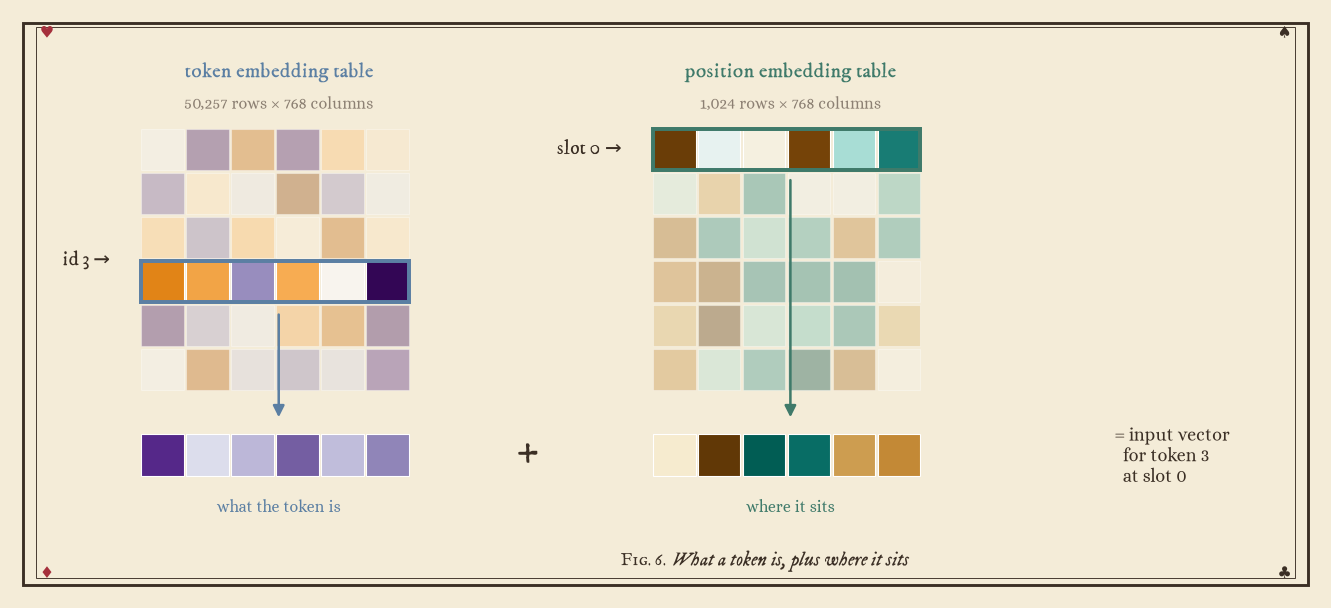</p>

Adding feels almost too crude to work. It works.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Builds both tables at GPT-2's real vocabulary size, runs one batch through them,
# and adds the results. Watch the shapes: this is the exact tensor that enters the model.

vocab_size, output_dim, max_length = 50257, 256, 4

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)     # table: 50257 x 256
pos_embedding_layer   = torch.nn.Embedding(max_length, output_dim)     # table: 4 x 256  (one row per slot)

loader = create_dataloader(alice, batch_size=8, max_length=max_length, stride=max_length, shuffle=False)
inputs, targets = next(iter(loader))                                   # inputs: (8, 4) token IDs

token_embeddings = token_embedding_layer(inputs)                       # (8, 4, 256): each ID -> its row
pos_embeddings   = pos_embedding_layer(torch.arange(max_length))       # (4, 256): rows 0,1,2,3 (arange = [0,1,2,3])
input_embeddings = token_embeddings + pos_embeddings                   # (8, 4, 256)
# NOTE: (8,4,256) + (4,256) works because PyTorch "broadcasts": the (4,256) grid is
# added to each of the 8 sequences. Same positions -> same position vectors.

print("token IDs        ", tuple(inputs.shape),           "  8 sequences x 4 tokens")
print("token embeddings ", tuple(token_embeddings.shape), "  ...each token -> 256 numbers")
print("pos embeddings   ", tuple(pos_embeddings.shape),   "  ...one per slot, shared by all 8")
print("input embeddings ", tuple(input_embeddings.shape), "  <- this is what the model eats")

---
### 🎯 Your turn (Step 2)
1. Run `show_tokens()` on your own name, on a URL, and on a line of Python. Which one is most expensive in tokens, and why does that matter for your API bill?
2. Change `stride` in `create_dataloader` from `8` to `1`. How many more training examples do you get? What is the risk of that much overlap?
3. Our `SimpleTokenizerV1` needed a few thousand entries to cover **one short book**. GPT-2 covers the whole internet with 50,257. Why doesn't the vocabulary need to be thousands of times larger?

---
# 👁️ Step 3 · Attention
### *(Chapter 3: the idea that changed everything)*

This is the centre of the whole notebook. Take your time here.

### The problem, stated properly

Consider this sentence:

> *"The Hatter offered Alice the teapot because **it** was empty."*

What does **"it"** refer to — the teapot, or Alice? Obviously the teapot. Now change one word:

> *"The Hatter offered Alice the teapot because **she** was thirsty."*

Now the pronoun points at Alice. Nothing about the *position* of the pronoun changed. The only way to resolve it is to **look back at the earlier words and decide which ones are relevant**.

Older models tried to squeeze the whole sentence into one fixed-size memory vector and read it back later — like taking notes on a sticky note, then throwing away the book. Long sentences overflowed the sticky note.

### The 2017 answer

> **Let every token look directly at every other token, and let the model learn *how much* to look.**

No bottleneck. No fixed-size summary. Each token builds its own custom blend of all the others. That blend is called a **context vector**, and the recipe for it is called **attention weights**.

Let's build it from nothing.

## 3.1 · Attention with no learnable parameters at all

Here is our toy sentence. Six tokens, each already turned into a 3-number embedding (in a real model it would be 768 numbers, which does not fit on a page).

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Hand-writes six tiny "embeddings" so we can watch every number. Rows are tokens,
# columns are the 3 dimensions of each embedding.

import torch

#                the      mad     hatter  poured   more     tea
inputs = torch.tensor(
    [[0.43, 0.15, 0.89],   # the     (x^1)
     [0.55, 0.87, 0.66],   # mad     (x^2)
     [0.57, 0.85, 0.64],   # hatter  (x^3)
     [0.22, 0.58, 0.33],   # poured  (x^4)
     [0.77, 0.25, 0.10],   # more    (x^5)
     [0.05, 0.80, 0.55]]   # tea     (x^6)
)                                                   # shape (6, 3): 6 tokens, 3 numbers each

WORDS = ["the", "mad", "hatter", "poured", "more", "tea"]
print(inputs.shape, "-> 6 tokens, 3 dimensions each")

**Step 1 — How relevant is every token to *this* token?**

Take token #2, `"mad"`, as our **query**. Score it against every token by taking a **dot product**. The dot product is just "multiply matching numbers and add them up," and it is large when two vectors point in a similar direction. That is our whole notion of similarity.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Computes one attention SCORE per token: how similar is each token to "mad"?
# torch.dot(a, b) = a[0]*b[0] + a[1]*b[1] + a[2]*b[2]

query = inputs[1]                                    # row 1 = "mad", shape (3,)

attn_scores_2 = torch.empty(inputs.shape[0])         # an empty tensor of 6 slots to fill
for i, x_i in enumerate(inputs):                     # loop over the 6 token vectors
    attn_scores_2[i] = torch.dot(query, x_i)         # similarity between "mad" and token i

for w, s in zip(WORDS, attn_scores_2):
    print(f"  score(mad, {w:<7}) = {s:.4f}")

print("\n(A dot product of two vectors a, b is just sum(a_i * b_i).)")
print("Manual check:", sum(query[i] * inputs[0][i] for i in range(3)).item(), "vs", attn_scores_2[0].item())

**Step 2 — Turn scores into weights that sum to 1.**

Raw scores can be any size. We want a set of proportions — a recipe. `softmax` does this: it exponentiates (making everything positive and exaggerating differences) then divides by the total.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# softmax turns the 6 scores into 6 positive numbers that add up to exactly 1.
# dim=0 = "along the only axis we have" (these scores are a 1-D tensor).

attn_weights_2 = torch.softmax(attn_scores_2, dim=0)

for w, s in zip(WORDS, attn_weights_2):
    bar = "█" * int(s * 100)                          # a crude bar chart in text
    print(f"  {w:<7} {s:.4f}  {bar}")

print(f"\nsum = {attn_weights_2.sum():.4f}   <- it's a proper recipe now (should print 1.0000)")

**Step 3 — Blend.**

Multiply each token's vector by its weight and add them all up. The result is `"mad"`, *rewritten in light of its neighbours*.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Weighted sum: (6 weights) @ (6 x 3 vectors) -> one 3-number vector.
# The '@' here is a vector-matrix product: 0.14*the + 0.24*mad + 0.23*hatter + ...

context_vec_2 = attn_weights_2 @ inputs              # (6,) @ (6, 3) -> (3,)

print("original 'mad':        ", inputs[1])
print("context-aware 'mad':   ", context_vec_2)
print("\nThat's it. That is attention: score -> softmax -> weighted sum.")

<p style="text-align:center">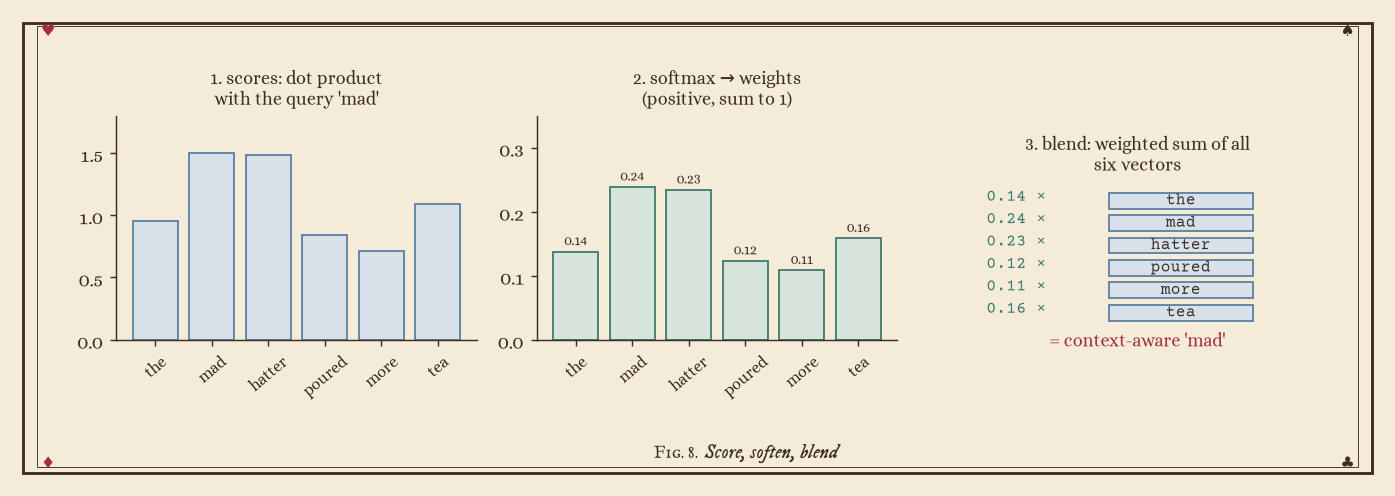</p>

### The same thing for all six tokens, in two lines

Everything above was a `for` loop over one token. Matrix multiplication does all six simultaneously — which is exactly why GPUs like transformers so much.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# The whole thing for every token at once:
#   inputs @ inputs.T   compares EVERY token with EVERY token  -> (6, 6) score grid
#   softmax(dim=-1)     normalises each ROW to sum to 1        -> (6, 6) weight grid
#   weights @ inputs    blends                                  -> (6, 3) one context vector per token

attn_scores  = inputs @ inputs.T                     # (6,3) @ (3,6) -> (6,6)
attn_weights = torch.softmax(attn_scores, dim=-1)    # dim=-1: normalise along the last axis = across each row
all_context_vecs = attn_weights @ inputs             # (6,6) @ (6,3) -> (6,3)

print("attention weight matrix:\n")
print(f"{'':<9}" + "".join(f"{w:>9}" for w in WORDS))
for w, row in zip(WORDS, attn_weights):
    print(f"{w:<9}" + "".join(f"{v:>9.3f}" for v in row))

print("\nRow i = 'how much does token i pay attention to each token?'")
print("Every row sums to 1:", attn_weights.sum(dim=-1))

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Defines plot_attention(), a heatmap of an attention matrix that we'll reuse all
# through the notebook, and draws our first one.

import matplotlib.pyplot as plt

def plot_attention(weights, words, title, ax=None):
    """Heatmap of an attention matrix: rows = the token looking, columns = the token looked at."""
    if ax is None:
        _, ax = plt.subplots(figsize=(4.6, 4))
    w = weights.detach().cpu().numpy()               # detach = drop gradient tracking; cpu = leave the GPU; numpy = plain array
    im = ax.imshow(w, cmap="YlOrBr", vmin=0, vmax=w.max())
    ax.set_xticks(range(len(words)), words, rotation=45, ha="right")
    ax.set_yticks(range(len(words)), words)
    ax.set_xlabel("attending TO")
    ax.set_ylabel("token")
    ax.set_title(title, fontsize=10)
    for i in range(len(words)):                      # write the number inside each cell
        for j in range(len(words)):
            if w[i, j] > 0:
                ax.text(j, i, f"{w[i, j]:.2f}", ha="center", va="center",
                        fontsize=7, color="white" if w[i, j] > w.max() * 0.6 else "black")
    return ax

plot_attention(attn_weights, WORDS, "Attention, no learned weights")
plt.tight_layout(); plt.show()

Notice the bright diagonal: with no trained parameters, every token mostly attends to **itself** (a vector's dot product with itself is large). That is a symptom of the missing ingredient — this version has **nothing to learn**. Let's fix that.

## 3.2 · Attention with trainable weights (the real thing)

The upgrade is to stop comparing raw embeddings, and instead let the model **project** each token into three different learned roles:

| Role | Think of it as | Question it answers |
|---|---|---|
| **Query** (Q) | your search box | *what am I looking for?* |
| **Key** (K) | the label on a library shelf | *what do I advertise about myself?* |
| **Value** (V) | the book on the shelf | *what do I actually contribute?* |

The analogy: token `"it"` sends out a query — *"I'm a pronoun, I need a noun."* Every token offers a key — *"I'm a noun, singular, an object."* Whichever keys match the query best get high weight, and their **values** get mixed into the answer.

<p style="text-align:center">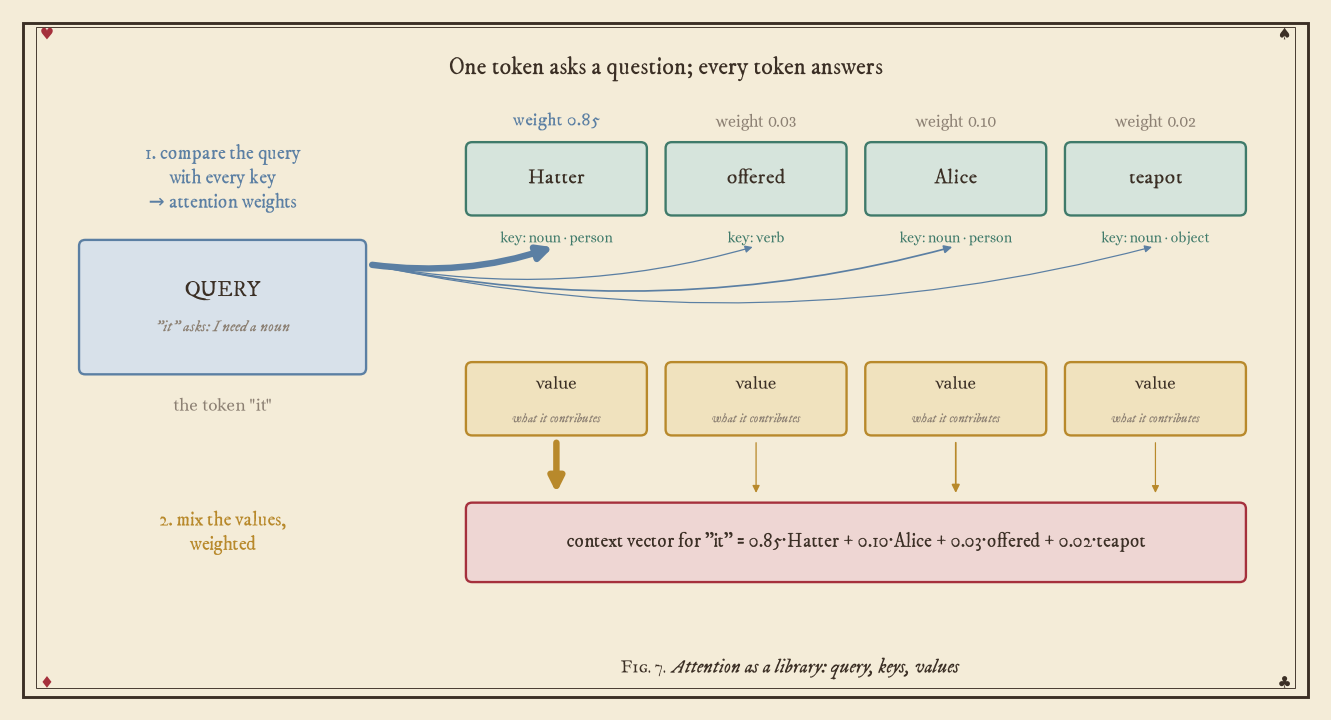</p>

Q, K and V come from three weight matrices. **These matrices are the parameters the model learns.** Everything the model knows about grammar and reference lives here.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Creates three random 3x2 matrices (W_query, W_key, W_value) and projects every
# token through each of them. nn.Parameter marks a tensor as "learnable" — for now
# we set requires_grad=False because we're just looking, not training.

torch.manual_seed(123)

d_in, d_out = inputs.shape[1], 2      # 3 numbers in, 2 numbers out (tiny, so we can read it)

W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)   # (3, 2)
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)   # (3, 2)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)   # (3, 2)

queries = inputs @ W_query            # (6,3) @ (3,2) -> (6,2): each token's "what am I looking for?"
keys    = inputs @ W_key              # (6,2): each token's "what do I advertise?"
values  = inputs @ W_value            # (6,2): each token's "what do I contribute?"

print("queries:\n", queries)
print("\nEach token now wears three different hats: query, key, value.")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Same three steps as before, but comparing QUERIES with KEYS instead of raw
# embeddings, and blending VALUES instead of raw embeddings. Plus one new thing:
# dividing the scores by the square root of the key size (explained below).

attn_scores = queries @ keys.T                       # (6,2) @ (2,6) -> (6,6): every query vs every key

d_k = keys.shape[-1]                                 # 2 = how many numbers per key
attn_weights = torch.softmax(attn_scores / d_k**0.5, dim=-1)   # scale, then softmax each row

context_vecs = attn_weights @ values                 # (6,6) @ (6,2) -> (6,2): one context vector per token

print("scaled scores:\n", attn_scores / d_k**0.5)
print("\ncontext vectors (one per token):\n", context_vecs)

**Why divide by √d_k?**

As vectors get longer, their dot products get bigger. Feed very large numbers into `softmax` and it goes all-or-nothing: one weight becomes ~1.0 and the rest ~0.0. That kills the gradients and training stalls. Dividing by √d_k keeps the scores in a civilised range. It's a numerical seatbelt — but an essential one, and it's why the paper is called *"Scaled Dot-Product Attention."*

Now let's package it as a proper PyTorch module, using `nn.Linear` (which is a matrix multiply with a better initialisation scheme).

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Same math, wrapped in an nn.Module — PyTorch's base class for anything with
# learnable parameters. Two rules of nn.Module:
#   __init__  : create the layers/parameters
#   forward   : say how input becomes output   (called automatically when you do module(x))
# nn.Linear(d_in, d_out) is a learnable matrix of shape (d_in, d_out) — "x @ W" as a layer.

import torch.nn as nn


class SelfAttention(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()                           # always call this first in an nn.Module
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):                            # x: (tokens, d_in)
        queries, keys, values = self.W_query(x), self.W_key(x), self.W_value(x)   # each (tokens, d_out)
        attn_scores  = queries @ keys.T                                            # (tokens, tokens)
        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)  # rows sum to 1
        return attn_weights @ values                                               # (tokens, d_out)


torch.manual_seed(789)
sa = SelfAttention(d_in, d_out)
print(sa(inputs))                                    # calling the module runs forward()

## 3.3 · Causal masking: no peeking at the answer

There is a cheat in what we just built. Token #1 (`"the"`) is allowed to attend to token #6 (`"tea"`) — a word that comes *later* in the sentence.

For a model whose entire job is to predict the next word, that is catastrophic. It's an open-book exam where the book is the answer sheet. The model would learn nothing except "copy the next token."

So we **mask the future**: when computing attention for position *i*, we forbid all positions > *i*. This is what the "causal" or "decoder-only" in "causal decoder-only transformer" means.

<p style="text-align:center">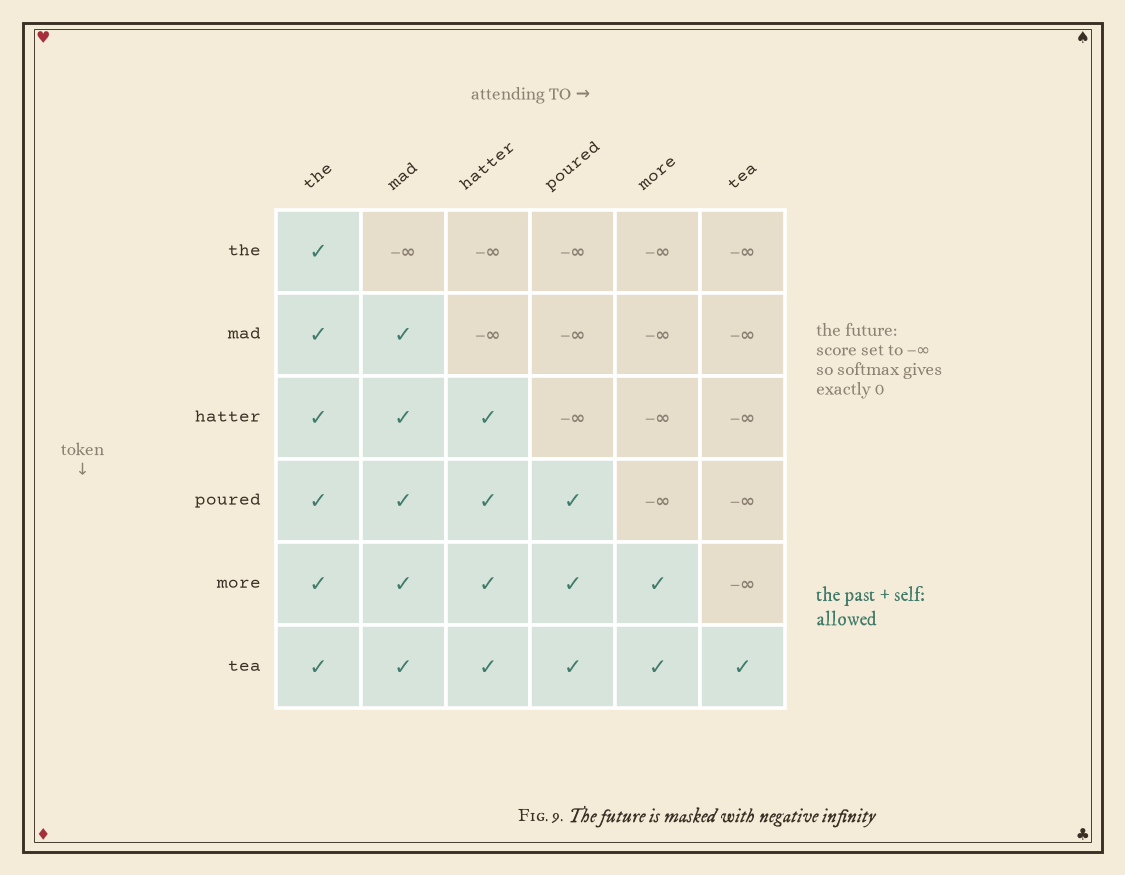</p>

The elegant implementation: set the masked **scores** to negative infinity *before* the softmax. `exp(-inf) = 0`, so those positions get exactly zero weight and the remaining weights still sum to 1 automatically. No renormalising by hand.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Builds the mask (1s above the diagonal = "the future"), stamps -inf onto those
# scores, and runs softmax. Watch the upper triangle become exactly 0.

queries, keys = sa.W_query(inputs), sa.W_key(inputs)
attn_scores = queries @ keys.T                       # (6, 6)
context_length = attn_scores.shape[0]                # 6

# torch.triu = "upper triangle": keep values on/above the diagonal, zero the rest.
# diagonal=1 shifts it up one step so the diagonal itself (a token looking at itself) stays allowed.
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
print("the mask (1 = block):\n", mask)

masked_scores = attn_scores.masked_fill(mask.bool(), -torch.inf)   # wherever mask is True, write -inf
print("\nscores with the future set to -inf:\n", masked_scores)

causal_weights = torch.softmax(masked_scores / keys.shape[-1] ** 0.5, dim=-1)
print("\nafter softmax (note the clean lower triangle):\n", causal_weights)

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Side by side: the cheating version and the honest version.

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
plot_attention(attn_weights, WORDS, "❌ Bidirectional (cheating)", axes[0])
plot_attention(causal_weights, WORDS, "✅ Causal (no peeking)", axes[1])
plt.tight_layout(); plt.show()

print("Token 1 can only see itself. Token 6 sees everything. That triangle is why")
print("an LLM generates text left-to-right, one token at a time.")

### Dropout: deliberate forgetting

One more ingredient. During training only, we randomly zero out some attention weights. It sounds destructive — it is — and it prevents the model from becoming over-reliant on any single connection. Surviving weights are scaled up to compensate.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Applies dropout to the attention weights so you can see what it actually does:
# random zeros, and every survivor multiplied by 1/(1-p) so the total stays the same.

torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)          # p = 0.5 here just to make it visible; real models use 0.1

print("before dropout:\n", causal_weights)
print("\nafter dropout (zeros appear, survivors are scaled up by 1/(1-p) = 2x):\n", dropout(causal_weights))

## 3.4 · Multi-head attention

Final upgrade, and the reason it's called "multi-head."

One attention mechanism learns **one kind of relationship**. But language has many at once: subject↔verb agreement, pronoun↔referent, adjective↔noun, quote↔speaker. So we run several attention mechanisms **in parallel**, each with its own Q/K/V matrices, and concatenate their outputs.

GPT-2 small uses **12 heads**. Each head gets 768 ÷ 12 = 64 dimensions to work with. Nobody tells the heads what to specialise in — they sort it out during training.

<p style="text-align:center">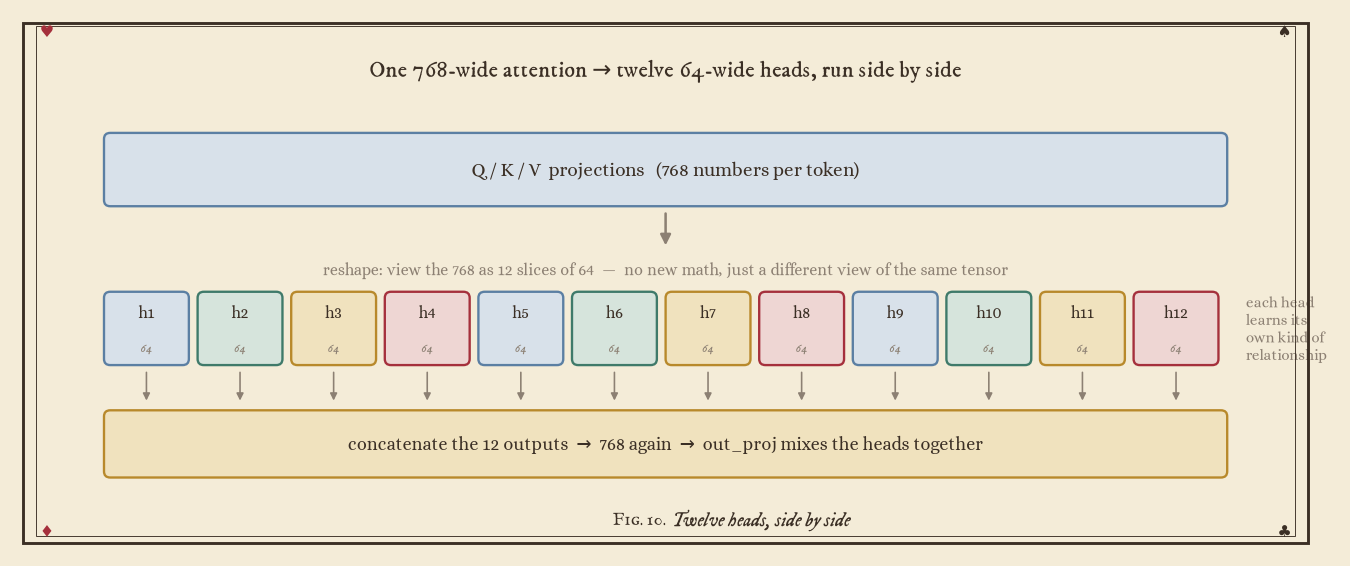</p>

The efficient implementation does not loop over heads. It computes one big Q, K, V and then *reshapes* to give the tensor a head dimension — same math, one matrix multiply.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# The full, production-grade attention module. This EXACT class is used inside
# every model for the rest of the notebook. Read the shape comments: the whole
# trick is reshaping (b, tokens, 768) into (b, heads, tokens, 64) and back.

class MultiHeadAttention(nn.Module):
    """Causal multi-head self-attention."""

    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must divide evenly among the heads"

        self.d_out     = d_out
        self.num_heads = num_heads
        self.head_dim  = d_out // num_heads          # each head gets a slice: 768 // 12 = 64

        self.W_query  = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key    = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value  = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)      # mixes the heads back together at the end
        self.dropout  = nn.Dropout(dropout)

        # register_buffer = "store this tensor with the model, but it's not a learnable parameter"
        # (so it moves to the GPU with the model and gets saved, but the optimizer ignores it)
        self.register_buffer(
            "mask", torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):                            # x: (b, num_tokens, d_in)
        b, num_tokens, _ = x.shape

        keys    = self.W_key(x)                      # (b, tokens, d_out)
        queries = self.W_query(x)                    # (b, tokens, d_out)
        values  = self.W_value(x)                    # (b, tokens, d_out)

        # Split the last axis into (heads, head_dim), then swap axes so heads come before tokens.
        # .view reshapes without copying; .transpose(1, 2) swaps axis 1 and axis 2.
        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)     # (b, heads, tokens, head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)  # (b, heads, tokens, head_dim)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)   # (b, heads, tokens, head_dim)

        attn_scores = queries @ keys.transpose(2, 3)                 # (b, heads, tokens, tokens): scores per head
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]       # crop the mask to this sequence length
        attn_scores.masked_fill_(mask_bool, -torch.inf)              # no peeking (the _ means "in place")

        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)   # rows sum to 1
        attn_weights = self.dropout(attn_weights)                    # only active during training

        context_vec = (attn_weights @ values).transpose(1, 2)        # (b, tokens, heads, head_dim)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)   # glue the heads: (b, tokens, d_out)
        # NOTE: .contiguous() lays the memory out in order after the transpose so .view is allowed
        return self.out_proj(context_vec)                            # (b, tokens, d_out)


torch.manual_seed(123)
batch = torch.stack((inputs, inputs), dim=0)          # (2, 6, 3): pretend batch of 2 identical sentences
mha = MultiHeadAttention(d_in=3, d_out=4, context_length=batch.shape[1],
                         dropout=0.0, num_heads=2)

print("in :", tuple(batch.shape))
print("out:", tuple(mha(batch).shape), "  (2 sentences, 6 tokens, 4 numbers each)")
print("\n🎉 You have just written the single most important function in modern AI.")

---
### 🎯 Your turn (Step 3)
1. In the `SelfAttention` class, delete the `/ keys.shape[-1] ** 0.5` scaling and print the attention weights. How much sharper does the distribution get?
2. Change `num_heads` from 2 to 4 in `MultiHeadAttention` (keep `d_out=4`). What is `head_dim` now? Try `num_heads=3` — why does the assertion fire?
3. **The big one:** attention compares every token with every other token. If you double the context length, how much more compute does attention need? (This quadratic cost is *the* reason long context windows are expensive, and the subject of a decade of research.)

---
# 🏗️ Step 4 · Assembling the Machine
### *(Chapter 4: the full GPT architecture)*

Attention is the engine. Now we build the car around it.

A GPT is a stack of identical **transformer blocks**. Each block does exactly two things:

1. **Look around** — multi-head attention (Step 3). *"Given everything before me, what's relevant?"*
2. **Think** — a small feed-forward network. *"Now let me process what I found."*

Wrapped around both: **layer normalisation** (keeps the numbers sane) and **residual connections** (keeps the gradients alive). Repeat the block 12 times, add embeddings at the bottom and an output layer at the top, and you have GPT-2.

Here's the configuration of the smallest real GPT-2, the one we're going to build and later load real weights into:

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# One dictionary holds every size that defines the model. Every class below reads
# from it, so changing a number here changes the whole architecture.

GPT_CONFIG_124M = {
    "vocab_size":     50257,   # how many different tokens exist (from BPE, Step 2)
    "context_length": 1024,    # the most tokens the model can look at in one go
    "emb_dim":        768,     # numbers per token, everywhere inside the model
    "n_heads":        12,      # attention heads per block (Step 3)
    "n_layers":       12,      # how many transformer blocks are stacked
    "drop_rate":      0.1,     # dropout probability during training
    "qkv_bias":       False,   # add bias terms to the Q/K/V projections? (GPT-2 did; we'll match it later)
}

for k, v in GPT_CONFIG_124M.items():
    print(f"  {k:<16} {v}")

## 4.1 · Layer normalisation

Deep networks have a plumbing problem: activations drift. After a few layers the numbers are either enormous or vanishingly small, and training falls apart.

**LayerNorm** fixes it with a blunt instrument. For each token, independently: subtract the mean, divide by the standard deviation. Mean 0, variance 1. Then multiply by a learned `scale` and add a learned `shift`, so the model can undo the normalisation if it turns out to be a bad idea for a particular feature.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Pushes two random inputs through a small layer, then normalises the output by hand
# so you can see the mean go to 0 and the variance to 1. Also draws the before/after.

torch.manual_seed(123)
batch_example = torch.randn(2, 5)                    # (2, 5): 2 examples, 5 features each, random normal numbers
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())    # nn.Sequential = run these layers one after another
out = layer(batch_example)                           # (2, 6)

print("raw layer output:\n", out)
print("\nmean per row:    ", out.mean(dim=-1).tolist())          # dim=-1: one mean PER ROW (per example)
print("variance per row:", out.var(dim=-1).tolist())

mean = out.mean(dim=-1, keepdim=True)                # (2, 1)  keepdim so it can be subtracted from (2, 6)
var  = out.var(dim=-1, keepdim=True)                 # (2, 1)
normed = (out - mean) / torch.sqrt(var)              # (2, 6): centre, then scale

torch.set_printoptions(sci_mode=False)               # print 0.0000 instead of 1e-08
print("\nafter normalising:\n", normed)
print("\nmean now ~0:", normed.mean(dim=-1).tolist())
print("var  now ~1:", normed.var(dim=-1).tolist())

# ── picture: the same numbers, before and after ──
fig, axes = plt.subplots(1, 2, figsize=(8, 2.8))
for ax, data, title in [(axes[0], out, "before LayerNorm"), (axes[1], normed, "after LayerNorm")]:
    for r in range(2):
        ax.plot(data[r].detach(), "o-", label=f"example {r}")
    ax.axhline(0, color="gray", lw=0.6); ax.set_title(title); ax.set_xlabel("feature"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# The same normalisation as a reusable layer, plus two learnable knobs (scale, shift).

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps   = 1e-5                                  # tiny constant so we never divide by zero
        self.scale = nn.Parameter(torch.ones(emb_dim))     # learnable: starts at 1 ("no change")
        self.shift = nn.Parameter(torch.zeros(emb_dim))    # learnable: starts at 0 ("no change")

    def forward(self, x):                                  # x: (..., emb_dim) — works on any leading shape
        mean = x.mean(dim=-1, keepdim=True)
        var  = x.var(dim=-1, keepdim=True, unbiased=False) # unbiased=False: divide by n, not n-1 (matches GPT-2)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift            # same shape as x


ln = LayerNorm(emb_dim=6)
out_ln = ln(out)
print("mean:", out_ln.mean(dim=-1).detach().tolist())      # detach: we don't need gradients for printing
print("var: ", out_ln.var(dim=-1, unbiased=False).detach().tolist(), "  (slightly under 1 because of eps)")

## 4.2 · GELU and the feed-forward network

After a token has gathered context from its neighbours, it needs to *do something* with it. That's the feed-forward network: expand to 4× the width, apply a non-linear activation, squeeze back down.

Why the expand-and-contract? The wide middle layer gives the model room to represent richer combinations before compressing back to the working size. About **two-thirds of a GPT's parameters live in these layers** — more than in attention.

The activation is **GELU** rather than the classic ReLU. ReLU has a hard corner at zero: everything negative is annihilated, and a neuron that goes negative can get permanently stuck (zero gradient, zero updates, dead forever). GELU curves gently through zero, so slightly-negative inputs still pass a whisper of signal — and a whisper of gradient.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Defines GELU (the formula GPT-2 uses) and plots it next to ReLU so you can see
# the difference: ReLU has a hard corner at 0, GELU has a soft dip just left of it.

class GELU(nn.Module):
    def forward(self, x):
        # This is the "tanh approximation" of GELU — the exact version uses the Gaussian CDF.
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))
        ))


x = torch.linspace(-3, 3, 200)                        # 200 evenly spaced numbers from -3 to 3
plt.figure(figsize=(7, 3))
for i, (fn, label) in enumerate([(GELU(), "GELU"), (nn.ReLU(), "ReLU")], 1):
    plt.subplot(1, 2, i)
    plt.plot(x, fn(x), lw=2)
    plt.axhline(0, color="gray", lw=0.5); plt.axvline(0, color="gray", lw=0.5)
    plt.title(f"{label}"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Look at the region just left of zero. ReLU: flat dead line. GELU: a gentle dip.")
print("That dip is a living gradient.")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# The feed-forward network: Linear (expand 4x) -> GELU -> Linear (contract).
# Input and output have the same shape, so it can slot into the block anywhere.

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),   # expand:   768 -> 3072
            GELU(),                                          # think (non-linearity)
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),   # contract: 3072 -> 768
        )

    def forward(self, x):                                    # x: (b, tokens, 768)
        return self.layers(x)                                # (b, tokens, 768)


ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768)                                    # (batch=2, tokens=3, emb=768) of random numbers
print("in :", tuple(x.shape), " -> out:", tuple(ffn(x).shape), " (shape preserved)")
# p.numel() = number of elements in a parameter tensor; sum over all of them = total parameter count
print(f"parameters in ONE feed-forward block: {sum(p.numel() for p in ffn.parameters()):,}")

## 4.3 · Residual connections: the gradient's fire escape

Stack 12 blocks and you hit the **vanishing gradient** problem. During backpropagation, the error signal gets multiplied by small numbers at every layer on the way down. By the time it reaches the early layers it's a rounding error, and those layers never learn.

The fix is almost insultingly simple: **add the input back to the output**. Because addition passes gradients through untouched, this creates a clean highway from the loss all the way down to layer 1.

<p style="text-align:center">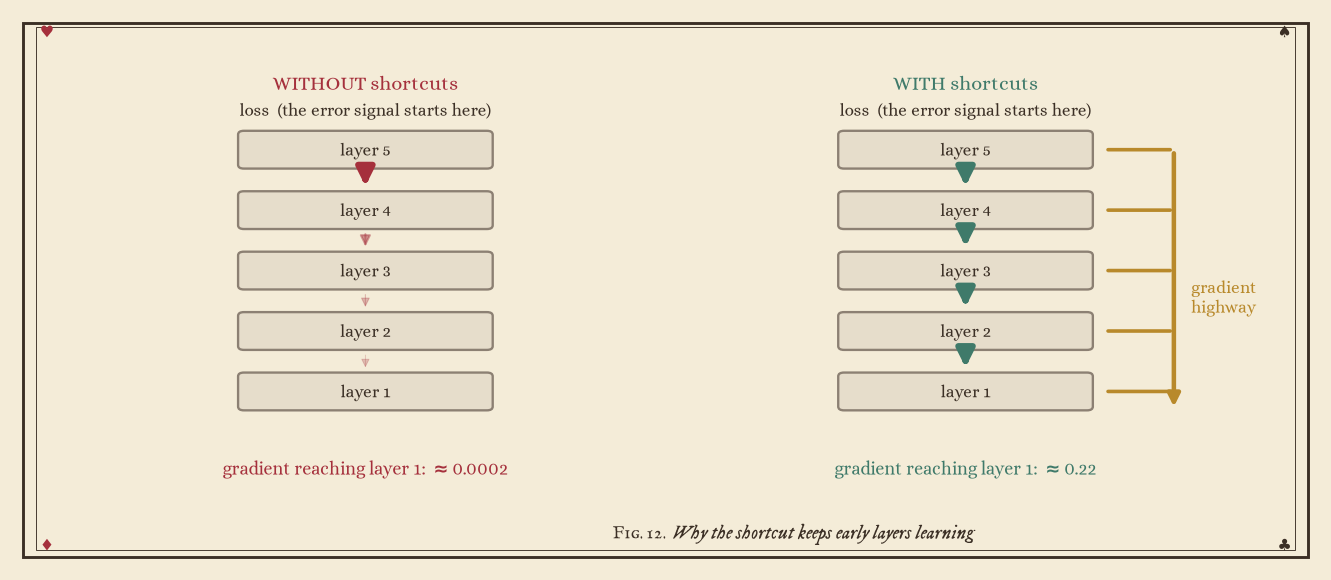</p>

Let's measure the difference rather than take it on faith.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Builds a 5-layer toy network twice — once plain, once with shortcuts — runs one
# backward pass through each, and prints how much gradient reaches every layer.
# Watch layer 0: without shortcuts its gradient is ~1000x smaller than the last layer's.

class ExampleDeepNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        # nn.ModuleList = a Python list that PyTorch knows contains layers (so their parameters are tracked)
        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[i], layer_sizes[i + 1]), GELU())
            for i in range(len(layer_sizes) - 1)
        ])

    def forward(self, x):
        for layer in self.layers:
            out = layer(x)
            # the shortcut: add the input back, if the shapes allow it
            x = x + out if (self.use_shortcut and x.shape == out.shape) else out
        return x


def print_gradients(model, x, label):
    loss = nn.MSELoss()(model(x), torch.tensor([[0.]]))  # a made-up loss: distance from 0
    loss.backward()                                     # backpropagation: compute d(loss)/d(every parameter)
    print(label)
    for name, param in model.named_parameters():
        if "weight" in name:
            # param.grad holds the gradient after .backward(); abs().mean() = its typical size
            print(f"   {name:<22} mean |gradient| = {param.grad.abs().mean().item():.6f}")


layer_sizes  = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])

torch.manual_seed(123)
print_gradients(ExampleDeepNetwork(layer_sizes, False), sample_input, "❌ WITHOUT shortcuts:")
print()
torch.manual_seed(123)
print_gradients(ExampleDeepNetwork(layer_sizes, True), sample_input, "✅ WITH shortcuts:")

print("\nLook at layer 0. Without shortcuts its gradient is ~1000x smaller than the last layer's.")
print("It is barely learning. With shortcuts, every layer gets a real signal.")

## 4.4 · The transformer block

Now put it together. Note the **pre-norm** ordering — normalise *before* attention and *before* the feed-forward, with the residual added after. GPT-2 does it this way and it trains far more stably than the original 2017 post-norm design.

<p style="text-align:center">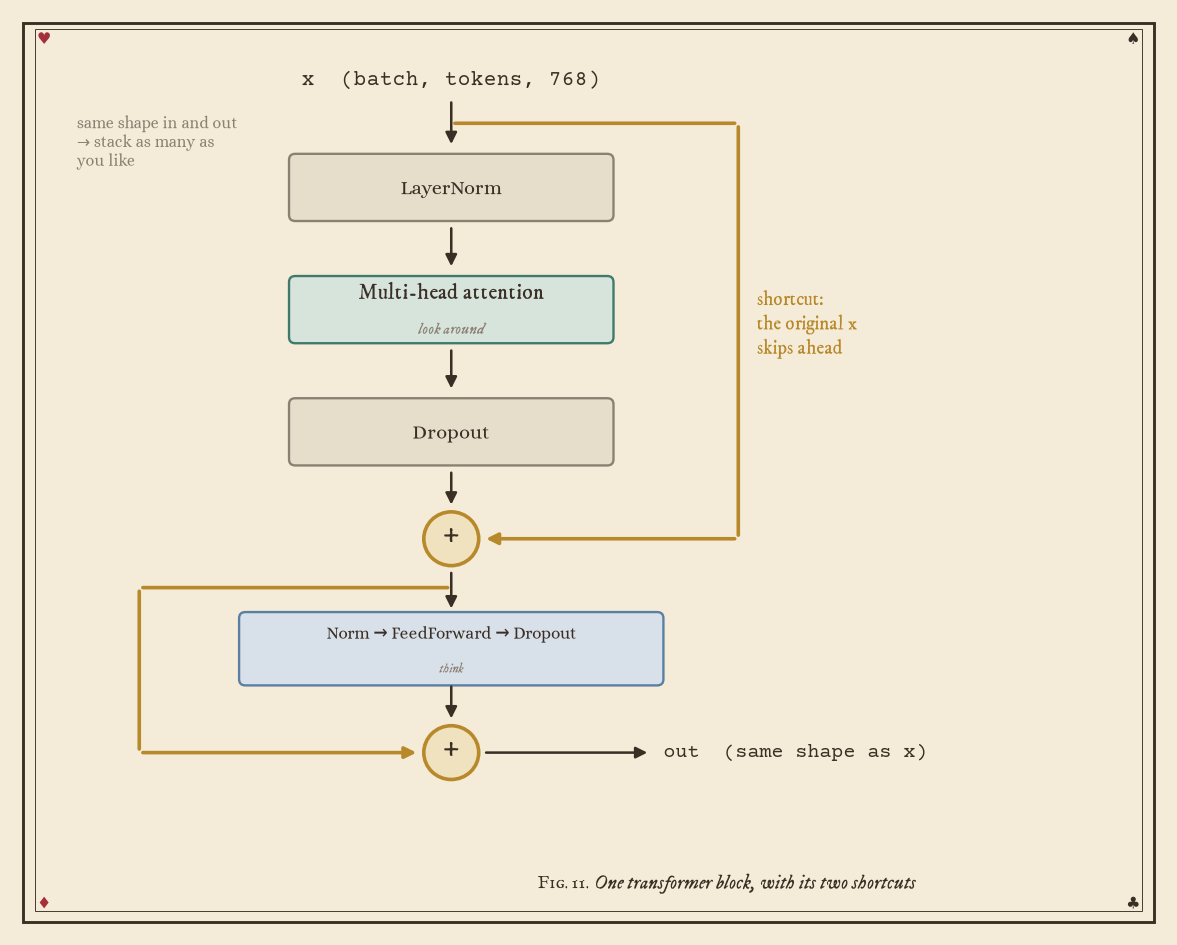</p>

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# One transformer block = the picture above, in code. Two sub-blocks, each wrapped
# in "save x -> normalise -> do the work -> dropout -> add x back".

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(                 # from Step 3
            d_in=cfg["emb_dim"], d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"], dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff    = FeedForward(cfg)                  # from 4.2
        self.norm1 = LayerNorm(cfg["emb_dim"])         # from 4.1 (one per sub-block)
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):                              # x: (b, tokens, emb_dim)
        # ── sub-block 1: look around ──
        shortcut = x                                   # remember the input
        x = self.norm1(x)
        x = self.att(x)                                # (b, tokens, emb_dim)
        x = self.drop_shortcut(x)
        x = x + shortcut                               # residual: add the input back

        # ── sub-block 2: think about it ──
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)                                 # (b, tokens, emb_dim)
        x = self.drop_shortcut(x)
        x = x + shortcut
        return x                                       # same shape as it came in


torch.manual_seed(123)
block = TransformerBlock(GPT_CONFIG_124M)
x = torch.rand(2, 4, 768)                              # (batch=2, tokens=4, emb=768)
print("in :", tuple(x.shape))
print("out:", tuple(block(x).shape), " <- same shape, which is why we can stack these forever")
print(f"\nparameters in one block: {sum(p.numel() for p in block.parameters()):,}")

## 4.5 · The whole GPT

Embeddings at the bottom, twelve blocks in the middle, a normalisation and an output layer on top. That's the entire model.

<p style="text-align:center">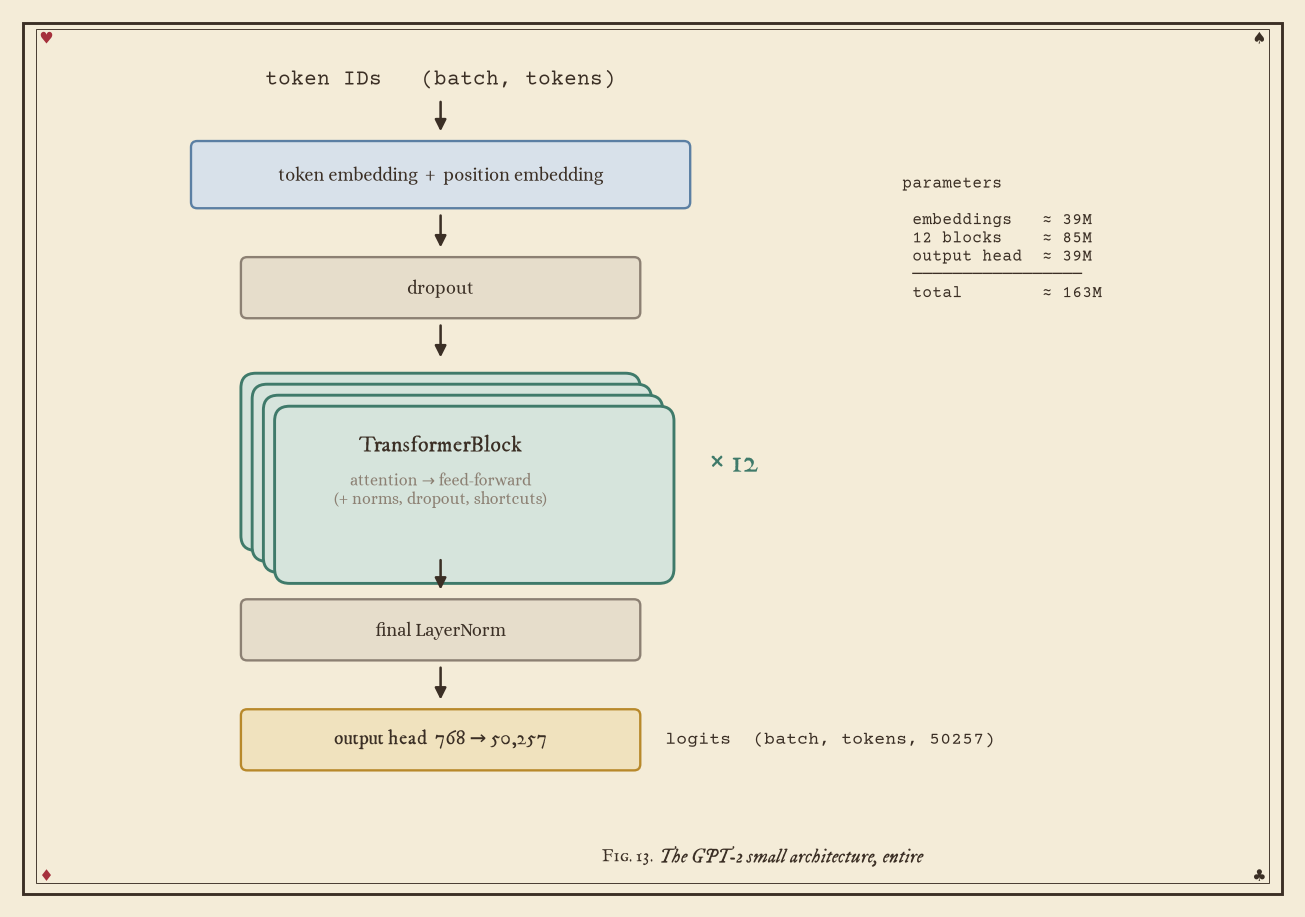</p>

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# The whole thing. ~30 lines of code, 163 million parameters.
# forward() takes token IDs and returns "logits": one score per vocabulary entry,
# at every position. (Logits = raw scores before softmax turns them into probabilities.)

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb  = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])       # WHAT each token is   (Step 2)
        self.pos_emb  = nn.Embedding(cfg["context_length"], cfg["emb_dim"])   # WHERE each token sits (Step 2)
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # *[...] unpacks a list into separate arguments: Sequential(block, block, ..., block)
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])          # the stack (12 blocks)

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head   = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)   # 768 -> 50257 scores

    def forward(self, in_idx):                                  # in_idx: (b, tokens) of token IDs
        _, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)                       # (b, tokens, emb_dim)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))   # (tokens, emb_dim)
        # NOTE: device=in_idx.device creates the position indices on the same device (CPU/GPU) as the input

        x = self.drop_emb(tok_embeds + pos_embeds)              # (b, tokens, emb_dim)  broadcasting adds positions
        x = self.trf_blocks(x)                                  # (b, tokens, emb_dim)  through all 12 blocks
        x = self.final_norm(x)                                  # (b, tokens, emb_dim)
        return self.out_head(x)                                 # (b, tokens, vocab_size) = logits


torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

# torch.stack piles two 1-D tensors into a (2, 4) batch — they must be the same length
batch = torch.stack([
    torch.tensor(bpe.encode("Alice fell down the")),
    torch.tensor(bpe.encode("The Mad Hatter")),          # both are exactly 4 tokens
], dim=0)

logits = model(batch)
print("input  :", tuple(batch.shape),  " 2 sentences x 4 tokens")
print("output :", tuple(logits.shape), " 2 x 4 x 50,257")
print("\nFor EVERY position, the model outputs a score for EVERY possible next token.")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Counts the parameters and explains the famous "124M" number (which assumes the
# input embedding and output layer share one matrix — "weight tying" — we don't).

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

tied = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"With weight tying (as in the paper): {tied:,}  <- there's the famous '124M'")

print(f"\nMemory as float32: {total_params * 4 / 1024**2:.1f} MB    (4 bytes per number)")
print("\nFor scale: GPT-3 is ~1,400x bigger than this. Same code. More of it.")

## 4.6 · Generating text (from an untrained model)

To generate, we run the model, take the logits at the **last** position, pick a token, append it, and run again. Over and over. This is called **autoregressive** generation, and it is the only thing ChatGPT does.

```
   "Alice fell down the"  -> model -> pick " stairs"
   "Alice fell down the stairs" -> model -> pick " and"
   "Alice fell down the stairs and" -> model -> pick ...
```

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# generate_text_simple(): the generation loop, greedy version (always take the
# top-scoring token). Plus two tiny helpers to go text -> tensor -> text.

def generate_text_simple(model, idx, max_new_tokens, context_size):
    """Greedy generation: always take the highest-scoring token."""
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]          # keep only the last context_size tokens (the model's limit)
        with torch.no_grad():                      # we're predicting, not learning: skip gradient bookkeeping
            logits = model(idx_cond)               # (b, tokens, vocab)

        logits = logits[:, -1, :]                  # (b, vocab): only the LAST position's scores matter
        probas = torch.softmax(logits, dim=-1)     # scores -> probabilities (not strictly needed for argmax)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)   # (b, 1): the most likely token
        idx = torch.cat((idx, idx_next), dim=1)    # (b, tokens+1): append it and go again
    return idx


def text_to_token_ids(text, tokenizer):
    # .unsqueeze(0) adds a batch axis: (tokens,) -> (1, tokens). Models always expect a batch.
    return torch.tensor(tokenizer.encode(text, allowed_special={"<|endoftext|>"})).unsqueeze(0)

def token_ids_to_text(token_ids, tokenizer):
    # .squeeze(0) removes the batch axis again: (1, tokens) -> (tokens,)
    return tokenizer.decode(token_ids.squeeze(0).tolist())


model.eval()                                       # eval mode: turn dropout OFF (we want deterministic output)
out = generate_text_simple(
    model, text_to_token_ids("Alice fell down the", bpe),
    max_new_tokens=10, context_size=GPT_CONFIG_124M["context_length"])

print("🤖 An untrained 124M-parameter model says:\n")
print("  ", token_ids_to_text(out, bpe))
print("\nComplete gibberish — as it should be. Every one of those 163 million")
print("parameters is currently a random number. It has read nothing.")
print("\nNext step: we teach it to read.")

---
### 🎯 Your turn (Step 4)
1. Build a GPT-2 **medium** by changing the config to `emb_dim=1024, n_layers=24, n_heads=16`. How many parameters? (Large is `1280/36/20`, XL is `1600/48/25`.)
2. Print `model` to see the whole architecture. Count how many `LayerNorm` modules there are and work out why that number is what it is.
3. Comment out `pos_embeds` in `GPTModel.forward` (use `x = self.drop_emb(tok_embeds)`). The model still runs — what capability has it just lost forever?

---
# 🎓 Step 5 · Training WonderGPT
### *(Chapter 5: loss, gradients, and watching a model learn)*

Time to turn random numbers into a writer.

## 5.1 · How wrong is the model? (Cross-entropy loss)

Training needs a single number that says "how bad was that guess." Here's how we get it:

1. The model outputs 50,257 scores for the next token.
2. Softmax turns them into probabilities.
3. Look up the probability it assigned to the **correct** token.
4. Take the log, flip the sign, average over all positions.

That's **cross-entropy loss**. Low loss = the model gave high probability to the right answer.

<p style="text-align:center">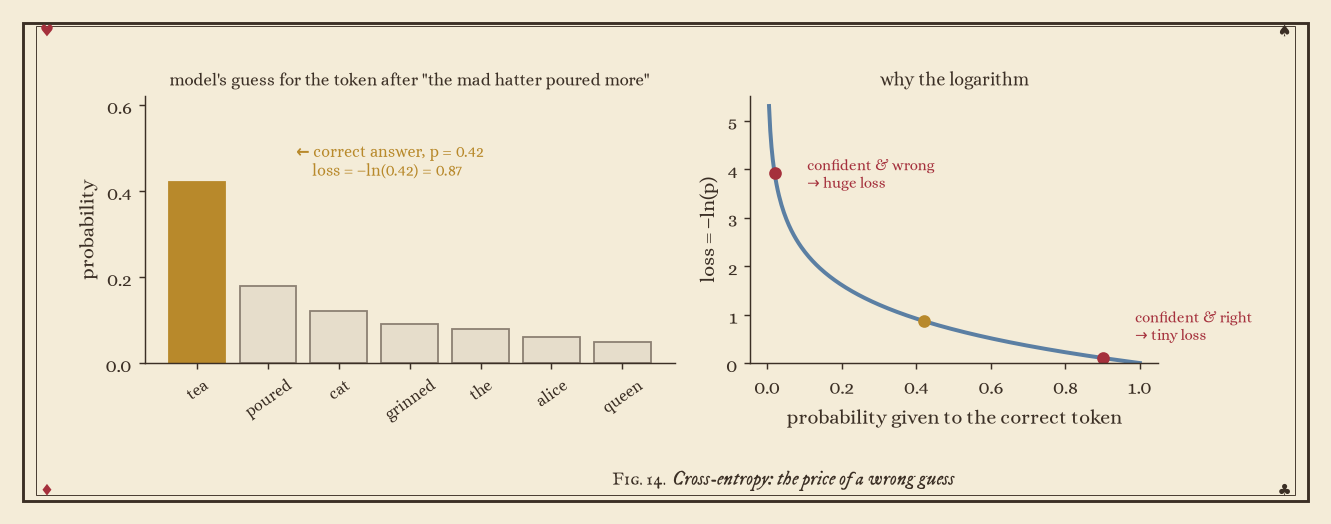</p>

Why the logarithm? Because probabilities multiply and get tiny; logs add and stay manageable. And because `-log(p)` punishes confident wrong answers brutally: assign 0.5 to the truth and you pay 0.69; assign 0.001 and you pay 6.9.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Runs two 3-token inputs through the (still random) model and pulls out the
# probability it gave to each CORRECT next token. Spoiler: about 1 in 50,000.

# Two 3-token inputs and the 3 tokens that should follow each one.
inputs  = torch.tensor([[44484, 3214,  866],      # "Alice fell down"
                        [  464, 4627,  367]])     # "The Mad H"
targets = torch.tensor([[ 3214,  866,  262],      # " fell down the"
                        [ 4627,  367, 1436]])     # " Mad H atter"

print("input 1 :", repr(bpe.decode(inputs[0].tolist())), "-> should continue:",
      repr(bpe.decode(targets[0].tolist())))

with torch.no_grad():
    logits = model(inputs)                        # (2, 3, 50257)
probas = torch.softmax(logits, dim=-1)            # (2, 3, 50257): each row of 50257 sums to 1
print("probabilities shape:", tuple(probas.shape))

# Fancy indexing: probas[0, [0,1,2], targets[0]] picks, for sequence 0, at positions 0,1,2,
# the probability of the target token at each position -> 3 numbers
target_probas_1 = probas[0, [0, 1, 2], targets[0]]
target_probas_2 = probas[1, [0, 1, 2], targets[1]]
print("\nprobability assigned to the right token, sequence 1:", target_probas_1)
print("probability assigned to the right token, sequence 2:", target_probas_2)
print("\n(1/50257 = 0.0000199. Random guessing. The model knows nothing yet.)")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Computes the loss by hand (log, negate, average) and then with PyTorch's built-in
# cross_entropy to show they agree. Then converts loss to "perplexity".

log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))   # cat = join the two lists -> 6 numbers
loss_manual = -log_probas.mean()
print("loss, computed by hand:", loss_manual.item())

# PyTorch does all of that in one call. It wants 2-D logits (rows, vocab) and 1-D targets, so:
#   logits.flatten(0, 1)  merges the batch and token axes: (2, 3, 50257) -> (6, 50257)
#   targets.flatten()     -> (6,)
loss_torch = torch.nn.functional.cross_entropy(logits.flatten(0, 1), targets.flatten())
print("loss, from cross_entropy:", loss_torch.item())

perplexity = torch.exp(loss_torch)                # e^loss
print(f"\nperplexity: {perplexity.item():,.0f}")

print("\nPERPLEXITY is loss made human-readable: 'the model is as confused as if it")
print("were choosing uniformly at random among this many options.'")
print("\nPure random guessing would be 50,257 (the whole vocabulary). We're WORSE")
print("than that, because the model isn't uniform — it is confidently wrong.")
print("A well-trained model gets down to roughly 20.")

# The random 163M model from Step 4 has served its purpose. Reclaim its 650 MB.
for _name in ("model", "logits", "probas", "block", "ffn"):
    globals().pop(_name, None)                    # delete the variable if it exists
free()
print("\n💾 freed the untrained 163M demo model")

## 5.2 · Loss over a whole dataset

Split *Alice* into a training set and a validation set. The training set is what the model learns from; the validation set is the honest exam it never studies for. When training loss keeps dropping but validation loss starts *rising*, the model has stopped learning language and started memorising the book. That gap is **overfitting**.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Cuts the book 90/10 by characters: first 90% to learn from, last 10% held out.

train_ratio = 0.90
split_idx   = int(train_ratio * len(alice))
train_data, val_data = alice[:split_idx], alice[split_idx:]

print(f"training characters:   {len(train_data):,}")
print(f"validation characters: {len(val_data):,}")
print(f"training tokens:       {len(bpe.encode(train_data)):,}")
print(f"validation tokens:     {len(bpe.encode(val_data)):,}")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Two helpers: loss for ONE batch, and average loss over a whole DataLoader.
# Both move data to the GPU with .to(device) — the model and its inputs must live
# on the same device.

def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)                                              # (b, tokens, vocab)
    return torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())


def calc_loss_loader(data_loader, model, device, num_batches=None):
    """Average loss over the first num_batches batches (or all of them)."""
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    num_batches = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))
    for i, (inp, tgt) in enumerate(data_loader):
        if i >= num_batches:
            break
        total_loss += calc_loss_batch(inp, tgt, model, device).item()       # .item(): tensor -> Python float
    return total_loss / num_batches

## 5.3 · Meet WonderGPT

A confession about scale. Training the full 124M model properly takes many GPU-hours and far more text than one Victorian novella. So we do the honest thing that actually fits on a free GPU: build a **smaller** model with the *identical architecture*, and train it for real.

| | GPT-2 small | **WonderGPT** |
|---|---|---|
| embedding dim | 768 | 384 |
| layers | 12 | 6 |
| heads | 12 | 6 |
| context | 1024 | 256 |
| parameters | 163M | ~49M |

Same code. Same math. Just fewer of everything — and small enough that you can watch it learn in a few minutes. (In Step 5.6 we'll load OpenAI's real 124M weights to see what a serious training run buys you.)

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Builds WonderGPT, moves it to the GPU, and makes the train/val DataLoaders.
# Then measures the loss BEFORE training and saves the model's first guesses for
# a prompt so we can compare before/after later.

WONDER_CONFIG = {
    "vocab_size":     50257,
    "context_length": 256,
    "emb_dim":        384,
    "n_heads":        6,
    "n_layers":       6,
    "drop_rate":      0.1,
    "qkv_bias":       False,
}

torch.manual_seed(123)
wonder = GPTModel(WONDER_CONFIG)
wonder.to(device)                                                 # move all parameters to the GPU

n = sum(p.numel() for p in wonder.parameters())
print(f"WonderGPT: {n:,} parameters ({n * 4 / 1024**2:.0f} MB)")

train_loader = create_dataloader(
    train_data, batch_size=8, max_length=WONDER_CONFIG["context_length"],
    stride=WONDER_CONFIG["context_length"] // 2,      # 50% overlap = twice as many examples
    drop_last=True, shuffle=True)

val_loader = create_dataloader(
    val_data, batch_size=8, max_length=WONDER_CONFIG["context_length"],
    stride=WONDER_CONFIG["context_length"],
    drop_last=False, shuffle=False)

print(f"\n{len(train_loader)} training batches, {len(val_loader)} validation batches")

with torch.no_grad():
    print(f"\nloss before any training -> train {calc_loss_loader(train_loader, wonder, device, 5):.3f}"
          f" | val {calc_loss_loader(val_loader, wonder, device, 5):.3f}")
print("(ln(50257) = 10.82 would be pure random guessing)")

# Save the untrained model's opinion about one prompt, for a before/after picture later
def next_token_probs(model, prompt):
    """Probabilities the model assigns to every possible next token after `prompt`."""
    model.eval()
    ids = text_to_token_ids(prompt, bpe).to(device)
    with torch.no_grad():
        logits = model(ids)[:, -1, :]                                 # (1, vocab): last position only
    model.train()
    return torch.softmax(logits, dim=-1)[0].cpu()                     # (vocab,) back on the CPU for plotting

PROBE_PROMPT = "The Queen of"
probs_before = next_token_probs(wonder, PROBE_PROMPT)

## 5.4 · The training loop

Here is the entire ritual of deep learning, and it never changes:

<p style="text-align:center">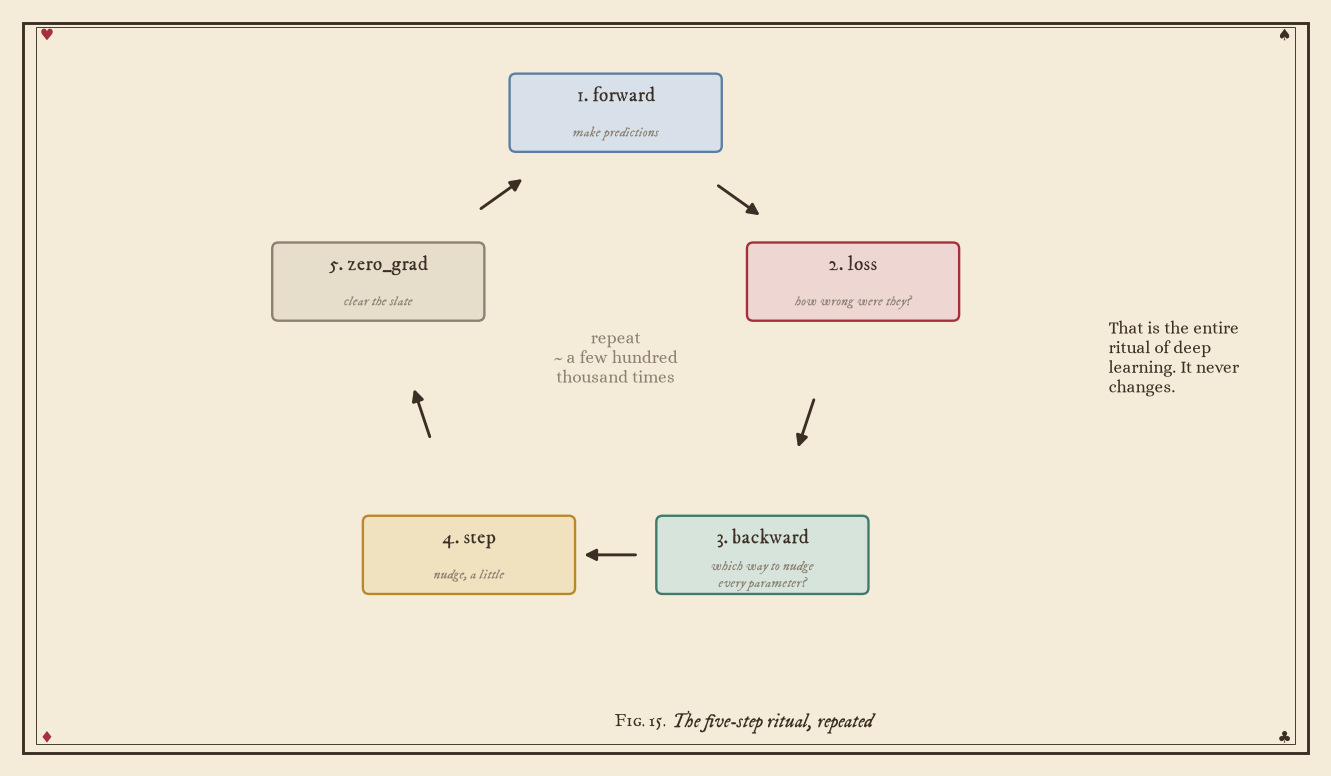</p>

Five lines. Run them a few hundred thousand times and you get ChatGPT.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# The training loop and two helpers: evaluate_model() measures train/val loss without
# learning, and generate_and_print_sample() lets the model speak after each epoch.

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()                                       # dropout off while measuring
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss   = calc_loss_loader(val_loader,   model, device, num_batches=eval_iter)
    model.train()                                      # back to training mode
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context, max_new_tokens=40):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]       # the model's context length, read off the position table
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(model, encoded, max_new_tokens, context_size)
    print("   📝", token_ids_to_text(token_ids, tokenizer).replace("\n", " "))
    model.train()


def train_model_simple(model, train_loader, val_loader, optimizer, device,
                       num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):                    # an epoch = one full pass over the training data
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()                                        # 5. clear old gradients
            loss = calc_loss_batch(input_batch, target_batch, model, device)   # 1. forward + 2. loss
            loss.backward()                                              # 3. backward: compute gradients
            optimizer.step()                                             # 4. nudge every parameter

            tokens_seen += input_batch.numel()                           # numel = number of elements = tokens in batch
            global_step += 1

            if global_step % eval_freq == 0:                             # every eval_freq steps, take stock
                tr, vl = evaluate_model(model, train_loader, val_loader, device, eval_iter)
                train_losses.append(tr); val_losses.append(vl); track_tokens.append(tokens_seen)
                print(f"Epoch {epoch+1} step {global_step:04d} | train {tr:.3f} | val {vl:.3f}")

        print(f"--- after epoch {epoch+1} WonderGPT says: ---")
        generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, track_tokens

### Press the button

⏱️ **Roughly 3–5 minutes on a Colab T4.** (On CPU, budget 30+ minutes — or drop `num_epochs` to 5.)

Watch the sample text after each epoch — that's the whole point of this cell. You are watching a mind assemble itself out of arithmetic.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Creates the optimizer (AdamW: the standard choice for transformers) and trains.
#   lr = learning rate = how big each nudge is
#   weight_decay = a gentle pull toward smaller weights, which reduces overfitting

import time

torch.manual_seed(123)
optimizer = torch.optim.AdamW(wonder.parameters(), lr=5e-4, weight_decay=0.1)

num_epochs = 15 if FAST else 30
start = time.time()

train_losses, val_losses, tokens_seen = train_model_simple(
    wonder, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=20, eval_iter=5,
    start_context="Alice was beginning to", tokenizer=bpe,
)

print(f"\n⏱️  training took {(time.time() - start) / 60:.1f} minutes")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Plots training and validation loss over the run. The gap between the two lines
# is the story of this step.

from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(6, 3.5))
    ax1.plot(epochs_seen, train_losses, label="training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="validation loss")
    ax1.set_xlabel("epochs"); ax1.set_ylabel("loss")
    ax1.legend(loc="upper right"); ax1.grid(alpha=0.3)
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))          # whole-number ticks on the x axis
    ax2 = ax1.twiny(); ax2.plot(tokens_seen, train_losses, alpha=0); ax2.set_xlabel("tokens seen")   # a second x axis
    fig.tight_layout(); plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))   # x positions for each measurement
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

### Read that graph carefully

The training loss dives. The validation loss dives too — and then flattens, or turns back up.

That divergence is **overfitting**, and here it is completely expected: we are asking a 49-million-parameter model to learn from a 40,000-token book. It has more than enough capacity to simply *memorise* Wonderland. It is not learning English; it is learning this one text.

The real fix is not a clever trick. It's **more data**. That single fact — that scale of data is the binding constraint — is most of the story of the last decade of AI.

### Before and after, in one picture

Remember the guesses we saved before training? Here is what the model thought should follow *"The Queen of"* then, versus now.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Compares the model's top-10 next-token guesses for the probe prompt before and
# after training. Before: a flat spread of nonsense. After: a sharp, sensible list.

probs_after = next_token_probs(wonder, PROBE_PROMPT)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, probs, title in [(axes[0], probs_before, "BEFORE training"), (axes[1], probs_after, "AFTER training")]:
    top_p, top_i = torch.topk(probs, 10)                              # the 10 highest probabilities and their token IDs
    labels = [repr(bpe.decode([i])) for i in top_i.tolist()]
    ax.barh(range(10)[::-1], top_p, color="#D8E1EA" if "BEFORE" in title else "#D6E4DC",
            edgecolor="#5B7FA3" if "BEFORE" in title else "#3F7A6A")
    ax.set_yticks(range(10)[::-1], labels)
    ax.set_xlabel("probability"); ax.set_title(f'{title}: next token after "{PROBE_PROMPT}"', fontsize=10)
    ax.set_xlim(0, max(probs_after.max().item() * 1.1, 0.05))
plt.tight_layout(); plt.show()

print("Same architecture, same prompt. The only thing that changed is 49 million numbers.")

## 5.5 · Decoding strategies: the personality dial

Our `generate_text_simple` always picks the single highest-scoring token. That's **greedy decoding**, and it's deterministic and dull — it loops, repeats itself, and takes no risks.

Two knobs fix this.

### Temperature

Instead of always taking the top token, *sample* from the probability distribution. **Temperature** rescales the logits before the softmax:

- `temperature < 1` — sharpen the distribution. Safe, focused, repetitive.
- `temperature = 1` — the model's honest opinion.
- `temperature > 1` — flatten the distribution. Creative, surprising, prone to nonsense.

Let's make it concrete with a tiny 9-word Wonderland vocabulary.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Takes one made-up set of 9 scores and shows how dividing by a temperature before
# softmax reshapes the probabilities.

vocab = {"alice": 0, "cat": 1, "grinned": 2, "hatter": 3, "poured": 4,
         "queen": 5, "shouted": 6, "tea": 7, "the": 8}
inverse_vocab = {v: k for k, v in vocab.items()}

# Pretend the model just read "the mad hatter" and produced these scores:
next_token_logits = torch.tensor([1.20, 3.60, 2.30, 0.85, 4.51, -1.99, 1.05, 5.20, 0.42])


def softmax_with_temperature(logits, temperature):
    return torch.softmax(logits / temperature, dim=0)      # divide first, THEN softmax


temperatures = [0.1, 1.0, 3.0]
scaled = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

x = torch.arange(len(vocab)); width = 0.25
fig, ax = plt.subplots(figsize=(8, 3.5))
for i, T in enumerate(temperatures):
    ax.bar(x + i * width - width, scaled[i], width, label=f"T = {T}")
ax.set_ylabel("probability"); ax.set_xticks(x, list(vocab.keys()), rotation=45, ha="right")
ax.legend(); ax.set_title("The same model, three temperatures")
plt.tight_layout(); plt.show()

print("T=0.1  -> almost always 'tea'. Reliable. Boring.")
print("T=1.0  -> usually 'tea', sometimes 'poured' or 'cat'.")
print("T=3.0  -> nearly flat. Even 'queen' gets a shot. Chaos.")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Actually rolls the dice 1,000 times at each temperature and counts what came up.
# torch.multinomial = "sample from these probabilities".

def sample_1000(probas, label):
    sample = torch.multinomial(probas, num_samples=1000, replacement=True)   # 1000 draws
    counts = torch.bincount(sample, minlength=len(vocab))                    # how many times each ID came up
    top = sorted(zip(counts.tolist(), inverse_vocab.values()), reverse=True)[:4]
    print(f"{label:<12} " + ",  ".join(f"{w} x{c}" for c, w in top))

torch.manual_seed(123)
print("Sampling the next word 1,000 times:\n")
for T, p in zip(temperatures, scaled):
    sample_1000(p, f"T = {T}")

### Top-k sampling

Temperature alone has a failure mode: even at `T=1`, there's a small chance of picking a genuinely absurd token — and one bad token derails everything after it.

**Top-k** puts up a guard rail: keep only the `k` highest-scoring tokens, throw the rest away (set them to `-inf`), and sample from what's left. You get creativity without catastrophe.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Keeps the 3 best scores and sets every other score to -inf, so softmax gives
# those tokens exactly 0 probability. (Same -inf trick as the causal mask!)

top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)       # the 3 largest values + their positions

print("kept:", [inverse_vocab[i] for i in top_pos.tolist()], "->", top_logits.tolist())

# torch.where(condition, if_true, if_false): elementwise choice
filtered = torch.where(next_token_logits < top_logits[-1],       # top_logits[-1] = the 3rd-best score
                       torch.tensor(float("-inf")), next_token_logits)
print("\nlogits after the guard rail:\n", filtered)
print("\nprobabilities:\n", torch.softmax(filtered, dim=0))
print("\nEverything outside the top 3 now has probability exactly zero.")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# generate(): the generation loop with both knobs (temperature, top_k) and an
# optional stop token. This replaces generate_text_simple from here on.

def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):
    """Generation with a personality dial."""
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]                                # (b, vocab): last position

        if top_k is not None:                                    # guard rail
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]                          # the k-th best score, per row
            logits = torch.where(logits < min_val,
                                 torch.tensor(float("-inf")).to(logits.device), logits)

        if temperature > 0.0:                                    # sample
            logits = logits / temperature
            logits = logits - logits.max(dim=-1, keepdim=True).values   # subtract the max: avoids overflow in exp()
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)   # (b, 1): a weighted random draw
        else:                                                    # greedy
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if eos_id is not None and idx_next.item() == eos_id:     # the model said "I'm done"
            break
        idx = torch.cat((idx, idx_next), dim=1)
    return idx


prompt = "Alice looked at the"
print(f'PROMPT: "{prompt}"\n')

for T, k, label in [(0.0, None, "greedy (T=0)"), (0.6, 25, "T=0.6, top-k 25"),
                    (1.0, 25, "T=1.0, top-k 25"), (1.6, 50, "T=1.6, top-k 50")]:
    torch.manual_seed(123)
    ids = generate(wonder, text_to_token_ids(prompt, bpe).to(device),
                   max_new_tokens=40, context_size=WONDER_CONFIG["context_length"],
                   temperature=T, top_k=k)
    print(f"── {label} ──")
    print("  ", token_ids_to_text(ids, bpe).replace("\n", " "), "\n")

## 5.6 · Saving, loading, and borrowing OpenAI's brain

Two lines to save a model, two to load it. Note that we save the `state_dict` (the parameters) rather than the object — the code that defines the architecture lives in your source file.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Saves the trained weights (+ optimizer state + config) to disk, then loads them
# back into a fresh model to prove the round trip works.

torch.save({
    "model_state_dict": wonder.state_dict(),        # state_dict = {parameter name: tensor} for the whole model
    "optimizer_state_dict": optimizer.state_dict(), # so you could resume training later
    "config": WONDER_CONFIG,
}, "wondergpt.pth")

print(f"saved wondergpt.pth ({os.path.getsize('wondergpt.pth') / 1024**2:.0f} MB)")

# Loading it back
checkpoint = torch.load("wondergpt.pth", weights_only=False)
reloaded = GPTModel(checkpoint["config"])
reloaded.load_state_dict(checkpoint["model_state_dict"])   # copy the saved numbers into the new model
reloaded.eval()
print("reloaded successfully ✅")

### Borrowing a brain

WonderGPT read one book. OpenAI's GPT-2 read about **40 gigabytes** of web text, on hardware we do not have, for weeks we do not have.

But here's the beautiful part: **our `GPTModel` class is architecturally identical to the real GPT-2.** So we can just... pour their trained parameters into our code and watch it come alive.

⚠️ **This downloads ~670 MB.** Set `LOAD_PRETRAINED = False` to skip it — but Steps 6 and 7 are much more fun with real weights, so grab a coffee and let it run.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Downloads OpenAI's GPT-2 small weights (converted to PyTorch format) and loads
# them into OUR GPTModel class. Two config changes to match the original exactly:
# qkv_bias=True (GPT-2 used bias terms) and drop_rate=0 (no dropout at inference).

LOAD_PRETRAINED = True     # set False to skip the 670 MB download

BASE_CONFIG = {
    "vocab_size":     50257,
    "context_length": 1024,
    "emb_dim":        768,
    "n_heads":        12,
    "n_layers":       12,
    "drop_rate":      0.0,     # no dropout at inference time
    "qkv_bias":       True,    # the original GPT-2 uses bias terms in Q/K/V
}

gpt2 = None
if LOAD_PRETRAINED:
    file_name = "gpt2-small-124M.pth"
    url = f"https://huggingface.co/rasbt/gpt2-from-scratch-pytorch/resolve/main/{file_name}"
    if not os.path.exists(file_name):
        print("downloading GPT-2 small (670 MB) — this takes a few minutes...")
        download(url, file_name)

    gpt2 = GPTModel(BASE_CONFIG)
    gpt2.load_state_dict(torch.load(file_name, weights_only=True))   # their numbers -> our layers
    gpt2.eval().to(device)
    print("✅ OpenAI's GPT-2 weights are now running inside YOUR code.")
else:
    print("skipped (LOAD_PRETRAINED = False)")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Lets the real GPT-2 finish two prompts, using our generate() function.

if gpt2 is not None:
    for prompt in ["Alice was beginning to get very tired of",
                   "The best thing about building a language model from scratch is"]:
        torch.manual_seed(123)
        ids = generate(gpt2, text_to_token_ids(prompt, bpe).to(device),
                       max_new_tokens=45, context_size=BASE_CONFIG["context_length"],
                       top_k=50, temperature=0.9)
        print(f'PROMPT: "{prompt}"')
        print("  ➜", token_ids_to_text(ids, bpe).replace("\n", " "), "\n")

    print("Same 50 lines of model code you wrote in Step 4. The only difference")
    print("between this and WonderGPT is what it read.")

### 🔬 Look inside: what 12 heads actually look at

We built the engine, so we can open the hood. Here is every attention head in one layer of the real GPT-2, reading our pronoun sentence from Step 3. Each head is a separate heatmap: rows are the token doing the looking, columns are what it looks at.

Nobody told these heads what to do. Watch for one that tracks the previous token, one that stares at the first token, and one that links **"it"** back to **"teapot"**.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Re-runs the attention math for ONE layer by hand (same code as Step 3's
# MultiHeadAttention.forward, minus the final blend) so we can grab the weights,
# then draws all 12 heads as a grid.

def attention_maps(model, text, layer):
    """Attention weights of every head in `layer` for `text`: shape (heads, tokens, tokens)."""
    model.eval()
    ids = text_to_token_ids(text, bpe).to(device)                          # (1, tokens)
    with torch.no_grad():
        x = model.tok_emb(ids) + model.pos_emb(torch.arange(ids.shape[1], device=device))
        for blk in model.trf_blocks[:layer]:                                # run the blocks BELOW our layer
            x = blk(x)
        blk = model.trf_blocks[layer]
        h = blk.norm1(x)                                                    # what this layer's attention sees
        att = blk.att
        b, n, _ = h.shape
        q = att.W_query(h).view(b, n, att.num_heads, att.head_dim).transpose(1, 2)   # (1, heads, n, head_dim)
        k = att.W_key(h).view(b, n, att.num_heads, att.head_dim).transpose(1, 2)
        scores = q @ k.transpose(2, 3)                                      # (1, heads, n, n)
        scores.masked_fill_(att.mask.bool()[:n, :n], -torch.inf)
        weights = torch.softmax(scores / att.head_dim ** 0.5, dim=-1)
    tokens = [bpe.decode([i]) for i in ids[0].tolist()]
    return weights[0].cpu(), tokens

if gpt2 is not None:
    sentence = "The Hatter offered Alice the teapot because it was empty."
    LAYER = 5
    maps, toks = attention_maps(gpt2, sentence, LAYER)

    fig, axes = plt.subplots(3, 4, figsize=(13, 9.5))
    for h, ax in enumerate(axes.flat):
        ax.imshow(maps[h], cmap="YlOrBr", vmin=0, vmax=1)
        ax.set_title(f"layer {LAYER}, head {h}", fontsize=9)
        ax.set_xticks(range(len(toks)), toks, rotation=90, fontsize=7)
        ax.set_yticks(range(len(toks)), toks, fontsize=7)
    plt.suptitle(f'GPT-2, layer {LAYER}: what each head looks at in "{sentence}"', fontsize=11)
    plt.tight_layout(); plt.show()

    print("Try LAYER = 0 (heads mostly look at the previous token) or LAYER = 10 (more abstract).")

### 🔬 Are the embeddings actually meaningful?

Back in Step 2 we claimed that training makes embedding vectors encode meaning. Let's check two ways: nearest neighbours by cosine similarity, and a 2-D map of the space.

Nobody ever told the model that "king" and "queen" are related. It worked that out from reading.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Pulls GPT-2's trained token-embedding table and, for a few words, finds the
# tokens whose vectors point in the most similar direction (cosine similarity).

if gpt2 is not None:
    emb = gpt2.tok_emb.weight.detach()                    # (50257, 768): the learned table
    emb_norm = emb / emb.norm(dim=1, keepdim=True)        # make every row length 1 -> dot product = cosine similarity

    def neighbours(word, k=6):
        ids = bpe.encode(word)
        if len(ids) != 1:
            return f"{word!r} isn't a single token"
        sims = emb_norm @ emb_norm[ids[0]]                # (50257,): similarity of every token to this one
        top = torch.topk(sims, k + 1).indices[1:]         # k best, skipping the word itself
        return ", ".join(repr(bpe.decode([i])) for i in top.tolist())

    print("Nearest neighbours in GPT-2's learned embedding space:\n")
    for w in [" king", " Monday", " happy", " Paris", " three", " purple"]:
        print(f"  {w!r:<12} -> {neighbours(w)}")

    print("\nDays cluster with days. Colours with colours. Numbers with numbers.")
    print("That structure was never programmed. It fell out of predicting the next word.")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Squashes 768 dimensions down to 2 (with PCA, via a matrix decomposition) for four
# groups of words, and scatters them. Related words land near each other.

if gpt2 is not None:
    groups = {
        "days":    [" Monday", " Tuesday", " Wednesday", " Thursday", " Friday", " Saturday", " Sunday"],
        "colours": [" red", " blue", " green", " purple", " yellow", " orange", " pink"],
        "numbers": [" one", " two", " three", " four", " five", " six", " seven"],
        "animals": [" cat", " dog", " rabbit", " horse", " mouse", " bird", " fish"],
    }
    words = [w for ws in groups.values() for w in ws]
    ids = [bpe.encode(w)[0] for w in words]
    X = emb[ids].cpu()                                    # (28, 768) — bring to the CPU for the maths + plotting
    X = X - X.mean(dim=0)                                 # centre the cloud
    U, S, V = torch.pca_lowrank(X, q=2)                   # PCA: find the 2 directions with the most spread
    coords = (X @ V[:, :2]).numpy()                       # (28, 2): project onto them

    colors = {"days": "#5B7FA3", "colours": "#A5303C", "numbers": "#3F7A6A", "animals": "#B8892B"}
    plt.figure(figsize=(7.5, 5.5))
    i = 0
    for name, ws in groups.items():
        pts = coords[i:i + len(ws)]; i += len(ws)
        plt.scatter(pts[:, 0], pts[:, 1], color=colors[name], label=name, s=50)
        for (x, y), w in zip(pts, ws):
            plt.annotate(w.strip(), (x, y), fontsize=8, xytext=(4, 3), textcoords="offset points")
    plt.legend(); plt.title("GPT-2's embedding space, squashed to 2-D"); plt.grid(alpha=0.25)
    plt.tight_layout(); plt.show()

    print("Four islands. The model drew this map itself, one next-token prediction at a time.")

---
### 🎯 Your turn (Step 5)
1. Re-run generation with `temperature=2.5, top_k=None`. How fast does it fall apart? Now `temperature=0.2`. What starts repeating?
2. Set `FAST = False` at the top and retrain WonderGPT for 30 epochs. Does the *validation* loss improve, or only the training loss? What does that tell you?
3. Train WonderGPT on `texts["sherlock"]` instead of `alice` (it's 4× longer). Does the overfitting gap shrink? Does its prose change character?
4. In `attention_maps`, try the sentence with **"she"** instead of **"it"**. Does any head move its attention from *teapot* to *Alice*?

---
# 🔍 Step 6 · Fine-tuning a Classifier: *Wonderland or Baker Street?*
### *(Chapter 6: classification fine-tuning)*

A pretrained model is a generalist that has absorbed an enormous amount about how language works. **Fine-tuning** takes that generalist and points it at one specific job — usually with a few hundred examples instead of 40 gigabytes.

There are two flavours:

| Flavour | You get | This step / next |
|---|---|---|
| **Classification** fine-tuning | a model that outputs one of N labels | Step 6 ⬅️ you are here |
| **Instruction** fine-tuning | a model that follows instructions | Step 7 |

**Our task:** give the model one sentence and ask *"Lewis Carroll or Arthur Conan Doyle?"*

This is genuinely non-trivial. Both are Victorian English, both are narrative fiction, both have dialogue. The signal is in register and vocabulary, not in obvious keywords. Let's see if 124 million parameters can develop literary taste.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Chops each book into standalone sentences. Alice speaks almost entirely inside
# quotation marks, so we look past an opening quote when checking for a capital letter.

import random

def sentences_from(text, min_len=45, max_len=280):
    """Chop a book into reasonably-sized standalone sentences."""
    flat = re.sub(r"\s+", " ", text)                                  # newlines/tabs -> single spaces
    # split after . ! ? — swallowing any closing quote that follows
    chunks = re.split(r"(?<=[.!?])[\"”’\')]*\s+", flat)

    out = []
    for s in chunks:
        s = s.strip()
        core = s.lstrip("“\"\'‘(_ ")      # look past opening quotes/brackets
        if not core or not (min_len <= len(s) <= max_len):
            continue
        if not core[0].isupper():                 # mid-sentence fragment -> skip
            continue
        if re.match(r"^(CHAPTER|ADVENTURE|[IVXL]+\.)", core):   # skip headings
            continue
        out.append(s)
    return out

wonderland_sents = sentences_from(texts["alice"])
baker_st_sents   = sentences_from(texts["sherlock"])

print(f"🐇 Wonderland sentences: {len(wonderland_sents):,}")
print(f"🔎 Baker Street sentences: {len(baker_st_sents):,}\n")
print("🐇 ", wonderland_sents[42])
print("🔎 ", baker_st_sents[42])

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Builds a balanced, labelled dataset (0 = Wonderland, 1 = Baker Street), shuffles
# it, and splits 70% train / 10% validation / 20% test.

rng = random.Random(123)
n_per_class = min(len(wonderland_sents), len(baker_st_sents), 900)    # same number from each book

data = ([(s, 0) for s in rng.sample(wonderland_sents, n_per_class)] +  # rng.sample = pick n at random, no repeats
        [(s, 1) for s in rng.sample(baker_st_sents,   n_per_class)])
rng.shuffle(data)

n_train, n_val = int(0.70 * len(data)), int(0.10 * len(data))
train_set = data[:n_train]
val_set   = data[n_train:n_train + n_val]
test_set  = data[n_train + n_val:]

LABELS = {0: "🐇 Wonderland", 1: "🔎 Baker Street"}
print(f"train {len(train_set)} | val {len(val_set)} | test {len(test_set)}")
print(f"class balance in training set: {sum(l for _, l in train_set) / len(train_set):.1%} Baker Street")

for text, label in train_set[:3]:
    print(f"\n{LABELS[label]}  {text[:110]}...")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# A Dataset for classification: tokenize every sentence, cut long ones, and pad
# short ones with <|endoftext|> (ID 50256) so every item is the same length.
# Same length = they can be stacked into one tensor per batch.

class AuthorDataset(Dataset):
    def __init__(self, rows, tokenizer, max_length=None, pad_token_id=50256):
        self.rows = rows
        self.encoded = [tokenizer.encode(t) for t, _ in rows]                        # list of ID lists
        self.max_length = max_length or max(len(e) for e in self.encoded)            # longest sentence, unless told otherwise
        self.encoded = [e[:self.max_length] for e in self.encoded]                   # truncate
        self.encoded = [e + [pad_token_id] * (self.max_length - len(e)) for e in self.encoded]   # pad

    def __getitem__(self, i):
        return (torch.tensor(self.encoded[i], dtype=torch.long),      # (max_length,) token IDs
                torch.tensor(self.rows[i][1], dtype=torch.long))      # the label: 0 or 1

    def __len__(self):
        return len(self.rows)


train_dataset = AuthorDataset(train_set, bpe)
val_dataset   = AuthorDataset(val_set,  bpe, max_length=train_dataset.max_length)   # same padding length everywhere
test_dataset  = AuthorDataset(test_set, bpe, max_length=train_dataset.max_length)

print("padded sequence length:", train_dataset.max_length, "tokens")

torch.manual_seed(123)
train_loader_cls = DataLoader(train_dataset, batch_size=8, shuffle=True,  drop_last=True,  num_workers=0)
val_loader_cls   = DataLoader(val_dataset,   batch_size=8, shuffle=False, drop_last=False, num_workers=0)
test_loader_cls  = DataLoader(test_dataset,  batch_size=8, shuffle=False, drop_last=False, num_workers=0)
print(f"{len(train_loader_cls)} training batches")

## 6.1 · Surgery: swapping the head

Right now the model's final layer maps 768 numbers → 50,257 scores (one per vocabulary token). We don't want 50,257 answers; we want **2**.

So we replace the output layer with a fresh `Linear(768, 2)`. Everything below it — all the language understanding — stays exactly as it was.

Then we **freeze** almost everything. Only three things stay trainable: the new 2-class head, the **last** transformer block (it does the task-specific reasoning), and the final layer norm.

<p style="text-align:center">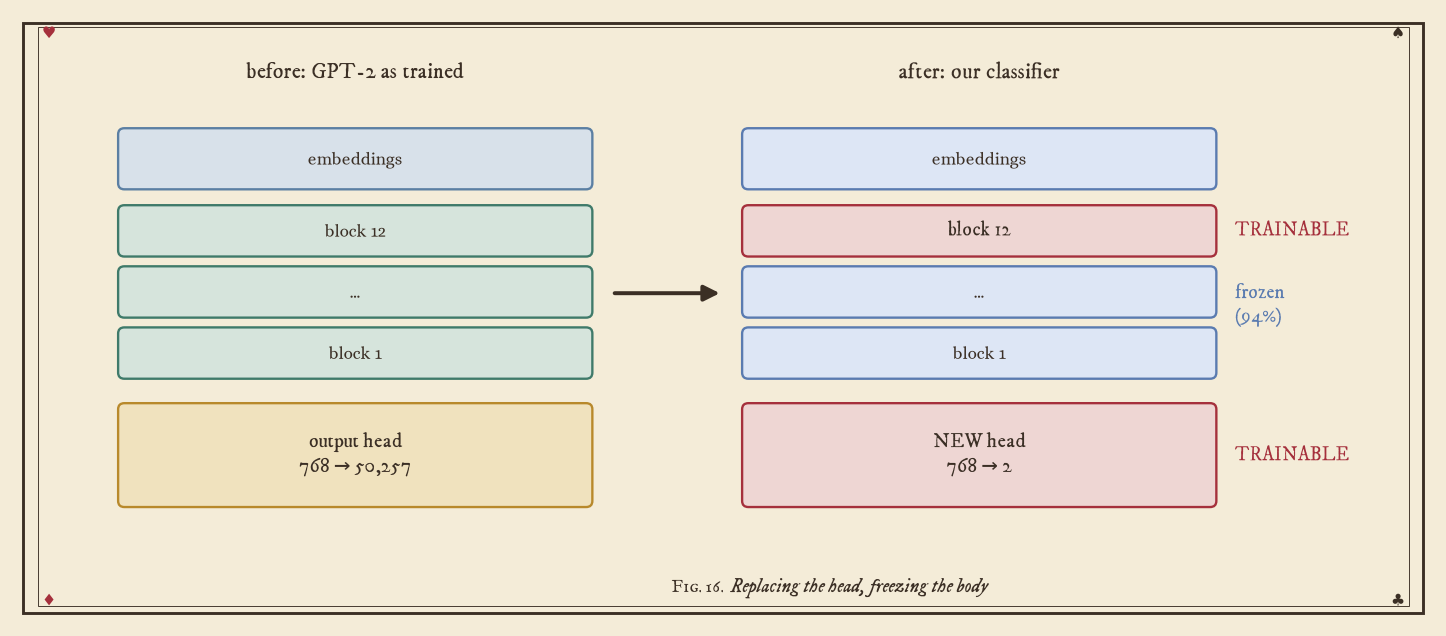</p>

Why freeze the rest? Speed, memory, and — most importantly — because with only ~1,500 examples, a fully unfrozen 124M-parameter model would obliterate everything it learned from the internet in about thirty seconds.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Copies GPT-2, freezes every parameter, swaps in a 2-output head, and un-freezes
# just the last block + final norm. requires_grad=False means "the optimizer must
# not touch this" — the parameter stays exactly as loaded.

import copy

assert gpt2 is not None, "Step 6 needs the pretrained weights. Re-run Step 5.6 with LOAD_PRETRAINED = True."

torch.manual_seed(123)
clf = copy.deepcopy(gpt2)                                # a full independent copy (so gpt2 stays pristine)

# 1. Freeze everything
for param in clf.parameters():
    param.requires_grad = False

# 2. New head: 768 -> 2. A freshly created layer is trainable by default.
clf.out_head = torch.nn.Linear(BASE_CONFIG["emb_dim"], 2)

# 3. Unfreeze the last block + final norm
for param in clf.trf_blocks[-1].parameters():            # [-1] = the last block in the stack
    param.requires_grad = True
for param in clf.final_norm.parameters():
    param.requires_grad = True

clf.to(device)

total     = sum(p.numel() for p in clf.parameters())
trainable = sum(p.numel() for p in clf.parameters() if p.requires_grad)
print(f"total parameters:     {total:,}")
print(f"trainable parameters: {trainable:,}  ({trainable / total:.1%})")
print("\nWe are moving less than 6% of the model. The other 94% is frozen expertise.")

### Which token do we read the answer from?

A subtle and important detail: we take the logits from the **last** token position, not the first.

Because attention is causal, only the final token has had a chance to see the *entire* sentence. Every earlier position is working with partial information. The last token is the only one holding the complete picture.

<p style="text-align:center">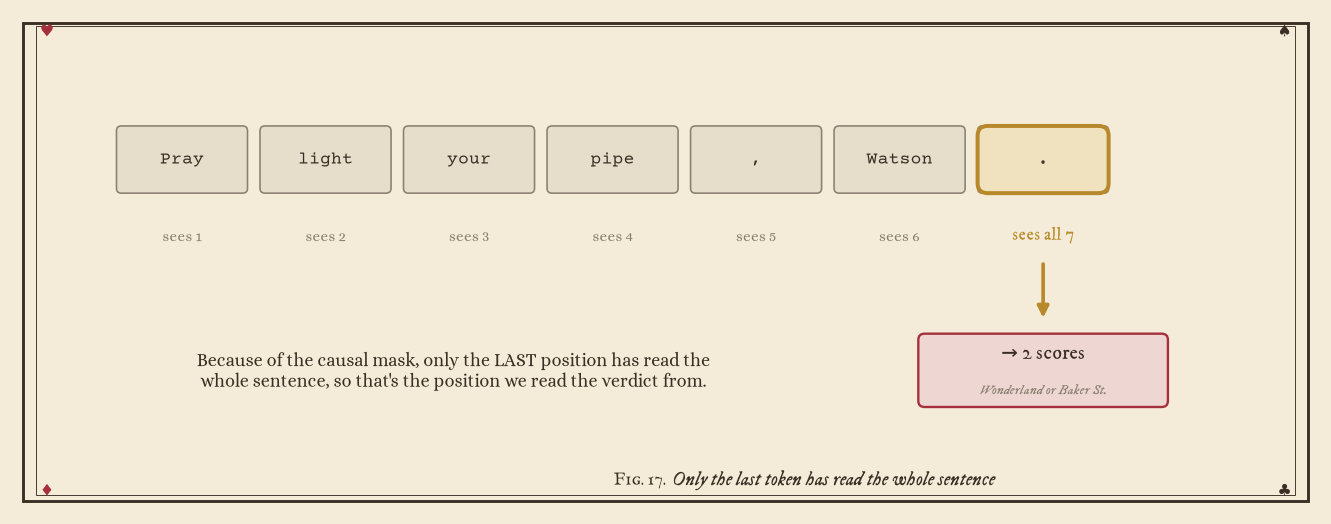</p>

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Runs one sentence through the modified model and reads the 2 scores at the
# last position. The head is still random, so the answer means nothing yet.

example = "You may have observed, Watson, that the mud on his left boot was of a distinctive red clay."
ids = torch.tensor(bpe.encode(example)).unsqueeze(0).to(device)     # (1, tokens)

with torch.no_grad():
    outputs = clf(ids)                                               # (1, tokens, 2)

print("output shape:", tuple(outputs.shape), " (1 sentence, N tokens, 2 classes)")
print("logits at the last token:", outputs[:, -1, :])                # [:, -1, :] = all batches, LAST token, all classes
print("probabilities:", torch.softmax(outputs[:, -1, :], dim=-1))
print("\nThe new head is random, so a single prediction can look confident while")
print("meaning nothing. Across the whole dataset it averages out to chance:")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Accuracy and loss helpers for classification. The only difference from Step 5's
# versions: we look at ONE position (the last) and compare with ONE label per row.

def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct, total = 0, 0
    num_batches = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))
    for i, (inp, tgt) in enumerate(data_loader):
        if i >= num_batches:
            break
        inp, tgt = inp.to(device), tgt.to(device)
        with torch.no_grad():
            logits = model(inp)[:, -1, :]                 # (b, 2): last token only
        correct += (torch.argmax(logits, dim=-1) == tgt).sum().item()   # count rows where the top score is the right label
        total += tgt.shape[0]
    return correct / total


def calc_loss_batch_cls(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]                 # (b, 2)
    return torch.nn.functional.cross_entropy(logits, target_batch)   # targets: (b,) of 0/1


def calc_loss_loader_cls(data_loader, model, device, num_batches=None):
    total_loss, n = 0., 0
    num_batches = len(data_loader) if num_batches is None else min(num_batches, len(data_loader))
    for i, (inp, tgt) in enumerate(data_loader):
        if i >= num_batches:
            break
        total_loss += calc_loss_batch_cls(inp, tgt, model, device).item(); n += 1
    return total_loss / max(n, 1)


print(f"accuracy before fine-tuning: {calc_accuracy_loader(val_loader_cls, clf, device) * 100:.1f}%")
print("(50% = guessing. The head is random, so this is exactly what we expect.)")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# The classification training loop — the same five steps as Step 5, with accuracy
# measured at the end of every epoch.

def train_classifier(model, train_loader, val_loader, optimizer, device,
                     num_epochs, eval_freq, eval_iter):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    global_step = -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch_cls(input_batch, target_batch, model, device)
            loss.backward()
            optimizer.step()
            global_step += 1

            if global_step % eval_freq == 0:
                model.eval()
                with torch.no_grad():
                    tr = calc_loss_loader_cls(train_loader, model, device, eval_iter)
                    vl = calc_loss_loader_cls(val_loader,   model, device, eval_iter)
                model.train()
                train_losses.append(tr); val_losses.append(vl)
                print(f"Epoch {epoch+1} step {global_step:04d} | train {tr:.3f} | val {vl:.3f}")

        tr_acc = calc_accuracy_loader(train_loader, model, device, eval_iter)
        va_acc = calc_accuracy_loader(val_loader,   model, device, eval_iter)
        print(f"  ✅ epoch {epoch+1}: train accuracy {tr_acc*100:.1f}% | val accuracy {va_acc*100:.1f}%")
        train_accs.append(tr_acc); val_accs.append(va_acc)

    return train_losses, val_losses, train_accs, val_accs

⏱️ **Roughly 2–4 minutes on a T4.** Watch the accuracy climb from a coin flip to literary criticism.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Trains. Note the optimizer is given ONLY the trainable parameters, and a much
# smaller learning rate than Step 5 — we're adjusting a trained model, not building one.

start = time.time()
torch.manual_seed(123)

optimizer = torch.optim.AdamW(
    [p for p in clf.parameters() if p.requires_grad], lr=5e-5, weight_decay=0.1)

num_epochs_cls = 3 if FAST else 5
cls_train_losses, cls_val_losses, cls_train_accs, cls_val_accs = train_classifier(
    clf, train_loader_cls, val_loader_cls, optimizer, device,
    num_epochs=num_epochs_cls, eval_freq=40, eval_iter=20)

print(f"\n⏱️  fine-tuning took {(time.time() - start) / 60:.1f} minutes")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Loss and accuracy curves side by side.

from matplotlib.ticker import MaxNLocator

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

steps = torch.linspace(0, num_epochs_cls, len(cls_train_losses))
axes[0].plot(steps, cls_train_losses, label="train")
axes[0].plot(steps, cls_val_losses, "-.", label="validation")
axes[0].set_xlabel("epochs"); axes[0].set_ylabel("loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title("Loss")

ep = range(1, num_epochs_cls + 1)
axes[1].plot(ep, [a * 100 for a in cls_train_accs], "o-", label="train")
axes[1].plot(ep, [a * 100 for a in cls_val_accs], "s-.", label="validation")
axes[1].axhline(50, color="gray", ls=":", label="coin flip")
axes[1].set_xlabel("epochs"); axes[1].set_ylabel("accuracy (%)"); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title("Accuracy")
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout(); plt.show()

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Final scores on ALL the data, and a confusion matrix on the test set: which
# mistakes does it make? (Rows = the true author, columns = the model's guess.)

print("FINAL SCORES (on all data, no shortcuts):\n")
for name, loader in [("train", train_loader_cls), ("validation", val_loader_cls), ("test", test_loader_cls)]:
    print(f"  {name:<12} {calc_accuracy_loader(loader, clf, device) * 100:.2f}%")

print("\nThe test set is sentences the model has never seen, from books it")
print("never trained on for this task. That number is the honest one.")

# confusion matrix
clf.eval()
confusion = torch.zeros(2, 2, dtype=torch.long)                       # [true][predicted]
with torch.no_grad():
    for inp, tgt in test_loader_cls:
        pred = torch.argmax(clf(inp.to(device))[:, -1, :], dim=-1).cpu()
        for t, p in zip(tgt, pred):
            confusion[t, p] += 1

fig, ax = plt.subplots(figsize=(4.2, 3.6))
ax.imshow(confusion, cmap="YlOrBr")
names = ["Wonderland", "Baker Street"]
ax.set_xticks([0, 1], names); ax.set_yticks([0, 1], names)
ax.set_xlabel("model said"); ax.set_ylabel("actually")
for i in range(2):
    for j in range(2):
        ax.text(j, i, confusion[i, j].item(), ha="center", va="center", fontsize=14,
                color="white" if confusion[i, j] > confusion.max() * 0.6 else "black")
ax.set_title("Test-set confusion matrix", fontsize=10)
plt.tight_layout(); plt.show()

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# whodunit(): classify any sentence you type, with the model's confidence.
# Then tries it on sentences I made up — none of these are in either book.

def whodunit(text, model=clf, max_length=None, pad_token_id=50256):
    """Classify a sentence and report the model's confidence."""
    model.eval()
    max_length = max_length or train_dataset.max_length
    ids = bpe.encode(text)[:max_length]                               # tokenize + truncate
    ids += [pad_token_id] * (max_length - len(ids))                   # pad, exactly as in training
    tensor = torch.tensor(ids, device=device).unsqueeze(0)            # (1, max_length)
    with torch.no_grad():
        logits = model(tensor)[:, -1, :]
    probs = torch.softmax(logits, dim=-1)[0]                          # (2,)
    pred = int(torch.argmax(probs))
    return LABELS[pred], probs[pred].item()


print("── Sentences the model has never seen (I made these up) ──\n")
tests = [
    "The dormouse was fast asleep in the teapot, and nobody thought it strange.",
    "I observed at once from the callus on his thumb that he had recently returned from Afghanistan.",
    "Off with their heads! shouted the Queen, quite purple with rage.",
    "The revolver lay upon the writing desk, and the window latch had been forced from without.",
    "Everything is quite absurd today, said the flamingo, refusing to be a mallet.",
    "Pray light your pipe, Watson, and let me lay the singular facts before you.",
]
for t in tests:
    verdict, confidence = whodunit(t)
    print(f"{verdict}  ({confidence:.0%})   {t[:78]}...")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Pushes the classifier off-distribution: modern sentences from neither book.

print("── Off-distribution sentences (neither book, modern English) ──\n")
for t in [
    "The neural network refused to converge, which was, frankly, very rude of it.",
    "I deduced from the timestamps that the deployment had failed at precisely 3 a.m.",
    "The talking teapot filed a complaint with the department of impossible things.",
]:
    verdict, confidence = whodunit(t)
    print(f"{verdict}  ({confidence:.0%})   {t}")

print("\n💡 The model has never seen a neural network or a deployment. It's matching")
print("   *register* — whimsy vs. deduction — which is exactly what we hoped for.")

---
### 🎯 Your turn (Step 6)
1. Write three sentences designed to **fool** the classifier — Wonderland vocabulary in a Holmesian sentence structure, or vice versa. Where does it break?
2. Unfreeze the last **two** transformer blocks instead of one. Better accuracy, or just slower?
3. Change the readout from the last token to the **first** token (`outputs[:, 0, :]`). Accuracy should collapse. Explain why in one sentence — the answer is in Step 3.

---
# 🐈 Step 7 · Teaching It To Obey: Meet Cheshire
### *(Chapter 7: instruction fine-tuning)*

GPT-2 can continue text. It cannot **follow instructions**. Ask it *"What is the opposite of hot?"* and it will happily continue with *"...asked the teacher. The class was silent."* It is autocompleting, not answering.

The leap from "text continuer" to "assistant" — the leap from GPT-3 to ChatGPT — is **instruction fine-tuning**. And the mechanism is almost anticlimactic:

> Show the model thousands of examples in the shape `INSTRUCTION → RESPONSE`, and train it to predict the response part.

That's it. No new architecture. No new loss function. Same next-token prediction, applied to a very carefully shaped dataset.

We're going to build an assistant called **Cheshire** 🐈 — because it appears when summoned, does what you ask, and then mostly vanishes.

## 7.1 · Making a dataset

Real instruction datasets are expensive: humans write tens of thousands of prompt/response pairs by hand. We'll generate ours from templates so it runs here and now — and so we can *verify* the answers exactly, which makes the results honest rather than vibes.

Six task types, each requiring a different little skill:

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Generates a few hundred instruction/answer pairs from small word lists. Every
# answer is exactly checkable, so we can GRADE the model later instead of guessing.

rng = random.Random(42)

OPPOSITES = {
    "hot": "cold", "big": "small", "fast": "slow", "happy": "sad", "light": "dark",
    "early": "late", "hard": "soft", "loud": "quiet", "rich": "poor", "young": "old",
    "wet": "dry", "full": "empty", "open": "closed", "sharp": "dull", "clean": "dirty",
    "brave": "cowardly", "wide": "narrow", "heavy": "light", "sweet": "sour", "near": "far",
    "strong": "weak", "smooth": "rough", "deep": "shallow", "tall": "short", "true": "false",
}
PLURALS = {
    "cat": "cats", "mouse": "mice", "child": "children", "leaf": "leaves", "box": "boxes",
    "goose": "geese", "tooth": "teeth", "wish": "wishes", "city": "cities", "knife": "knives",
    "person": "people", "foot": "feet", "story": "stories", "watch": "watches", "hero": "heroes",
    "loaf": "loaves", "berry": "berries", "fox": "foxes", "ox": "oxen", "half": "halves",
}
CAPITALS = {
    "France": "Paris", "Japan": "Tokyo", "Egypt": "Cairo", "Peru": "Lima", "Kenya": "Nairobi",
    "Italy": "Rome", "Norway": "Oslo", "India": "New Delhi", "Cuba": "Havana", "Greece": "Athens",
    "Chile": "Santiago", "Ghana": "Accra", "Nepal": "Kathmandu", "Spain": "Madrid", "Iraq": "Baghdad",
}
ANIMALS  = ["rabbit", "dormouse", "flamingo", "lobster", "caterpillar", "cat", "hedgehog",
            "walrus", "oyster", "griffin", "turtle", "eaglet", "lizard", "pigeon", "crab"]
NOUNS    = ["teapot", "clock", "mirror", "garden", "mushroom", "croquet", "tart", "riddle",
            "chessboard", "hourglass", "lantern", "kettle", "keyhole", "thimble", "pocketwatch"]
ADJS     = ["curious", "mad", "golden", "tiny", "enormous", "sleepy", "painted", "wandering"]


def make_examples(n_each=90):
    """Six instruction types. Every answer is exactly checkable."""
    ex = []                                          # each entry: {"instruction", "input", "output", "task"}

    # 1. antonyms
    for w, o in rng.sample(list(OPPOSITES.items()), min(n_each, len(OPPOSITES))):
        ex.append({"instruction": "Give the opposite of the following word.",
                   "input": w, "output": o, "task": "antonym"})

    # 2. plurals
    for w, p in rng.sample(list(PLURALS.items()), min(n_each, len(PLURALS))):
        ex.append({"instruction": "Write the plural form of the given noun.",
                   "input": w, "output": p, "task": "plural"})

    # 3. capitals
    for c, cap in rng.sample(list(CAPITALS.items()), min(n_each, len(CAPITALS))):
        ex.append({"instruction": "Name the capital city of the given country.",
                   "input": c, "output": cap, "task": "capital"})

    # 4. alphabetical sorting
    for _ in range(n_each):
        ws = rng.sample(ANIMALS, 3)
        ex.append({"instruction": "Sort these words in alphabetical order.",
                   "input": ", ".join(ws), "output": ", ".join(sorted(ws)), "task": "sort"})

    # 5. uppercase
    for _ in range(n_each):
        w = rng.choice(NOUNS)
        ex.append({"instruction": "Convert the input to uppercase.",
                   "input": w, "output": w.upper(), "task": "upper"})

    # 6. sentence building (a tiny bit of composition)
    for _ in range(n_each):
        a, n = rng.choice(ADJS), rng.choice(ANIMALS)
        ex.append({"instruction": "Write a short sentence using the given adjective and noun.",
                   "input": f"{a}, {n}", "output": f"The {a} {n} wandered through Wonderland.",
                   "task": "sentence"})

    rng.shuffle(ex)
    return ex


instruction_data = make_examples()
print(f"{len(instruction_data)} instruction examples\n")
for e in instruction_data[:4]:
    print(f"  [{e['task']:<8}] {e['instruction']}")
    print(f"             input: {e['input']!r}  ->  output: {e['output']!r}\n")

## 7.2 · The prompt template

Everything must be turned back into one flat string, because next-token prediction is all the model can do. We use the **Alpaca-style** template — the same one that launched a thousand open-source assistants:

```
Below is an instruction that describes a task. Write a response that
appropriately completes the request.

### Instruction:
Give the opposite of the following word.

### Input:
hot

### Response:
cold
```

Those `###` markers are not magic. They're just rare, consistent strings that the model learns to treat as structural signposts. Every chat model you have ever used has a template like this hiding underneath.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# format_input(): turns one example dict into the prompt string (everything except
# the answer). f-strings with \n\n build the multi-line layout.

def format_input(entry):
    text = ("Below is an instruction that describes a task. "
            "Write a response that appropriately completes the request."
            f"\n\n### Instruction:\n{entry['instruction']}")
    if entry.get("input"):                                   # some tasks have no input field
        text += f"\n\n### Input:\n{entry['input']}"
    return text


sample = instruction_data[0]
print(format_input(sample))
print(f"\n### Response:\n{sample['output']}")
print("\n" + "─" * 60)
print("The model sees ALL of this as one string of tokens and predicts it")
print("left to right, exactly like it predicted Alice in Wonderland.")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Splits 85% train / 5% validation / 10% test (held out for honest grading).

n = len(instruction_data)
train_i = instruction_data[:int(0.85 * n)]
val_i   = instruction_data[int(0.85 * n):int(0.90 * n)]
test_i  = instruction_data[int(0.90 * n):]
print(f"train {len(train_i)} | val {len(val_i)} | test {len(test_i)}")

## 7.3 · Batching with masks

Two wrinkles that only appear with instruction data:

**1. Padding.** Examples have different lengths, so we pad with `<|endoftext|>` (token 50256) to the longest in the batch.

**2. Masking the padding.** We do *not* want the model wasting capacity learning to predict endless padding. So in the **targets**, every padding token after the first is replaced with `-100`. PyTorch's `cross_entropy` ignores `-100` entirely — those positions contribute nothing to the loss.

(We keep the first `<|endoftext|>` as a real target so the model learns where to *stop*. That's how it knows to end its turn.)

<p style="text-align:center">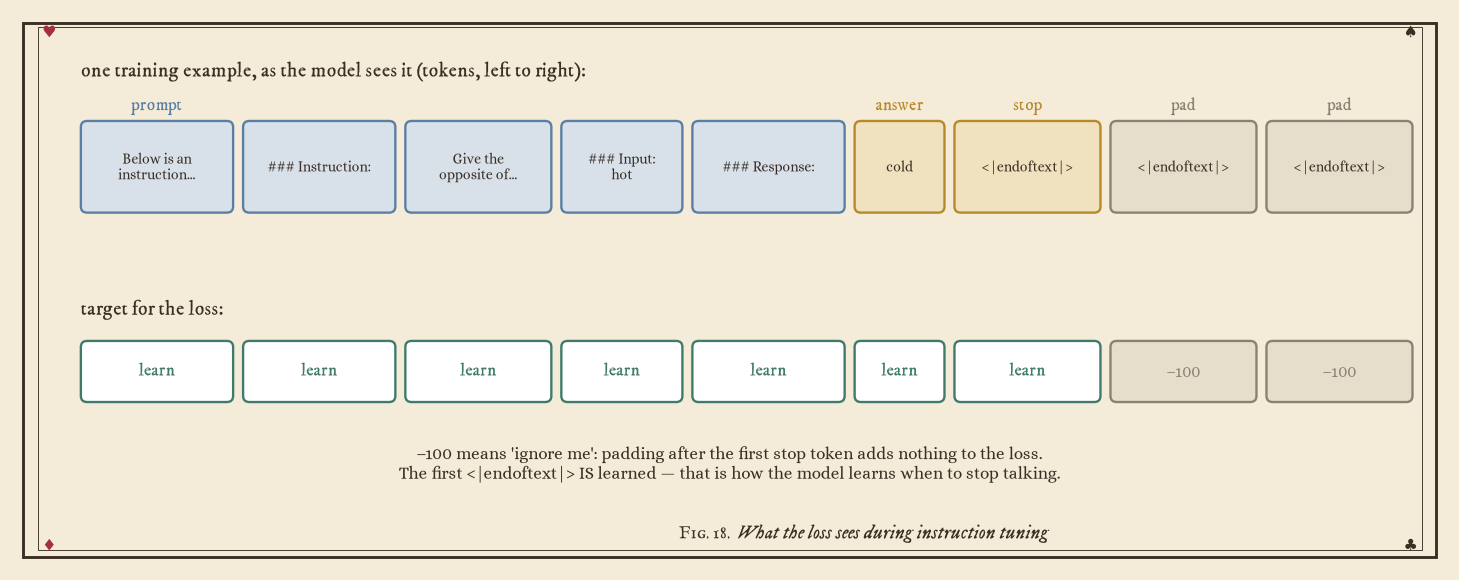</p>

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# custom_collate_fn(): takes a list of token-ID lists of different lengths and
# turns them into two equal-shaped tensors (inputs, targets), with padding masked
# out of the targets by -100. A "collate function" is what a DataLoader calls to
# glue individual items into one batch.

def custom_collate_fn(batch, pad_token_id=50256, ignore_index=-100,
                      allowed_max_length=None, device="cpu"):
    batch_max_length = max(len(item) + 1 for item in batch)          # +1 for the stop token we add
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item + [pad_token_id]                              # append one <|endoftext|> = "stop here"
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))   # pad to the batch's longest

        inputs  = torch.tensor(padded[:-1])     # everything but the last token
        targets = torch.tensor(padded[1:])      # shifted one right (the usual next-token setup)

        # mask all padding EXCEPT the first end-of-text token
        mask = targets == pad_token_id                                # True wherever the target is padding
        indices = torch.nonzero(mask).squeeze()                       # positions of those Trues
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index                       # keep the first, blank the rest

        if allowed_max_length is not None:                            # optional hard cap on length
            inputs, targets = inputs[:allowed_max_length], targets[:allowed_max_length]

        inputs_lst.append(inputs); targets_lst.append(targets)

    return torch.stack(inputs_lst).to(device), torch.stack(targets_lst).to(device)   # (b, L), (b, L)


demo = [[1, 2, 3, 4, 5], [6, 7], [8, 9, 10]]
i, t = custom_collate_fn(demo)
print("inputs:\n", i)
print("\ntargets (note the -100s):\n", t)
print("\nEvery -100 position is invisible to the loss function.")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Proof that cross_entropy really does skip -100: same logits, one target masked,
# different loss.

logits = torch.tensor([[-1.0, 1.0], [-0.5, 1.5], [-0.5, 1.5]])
print("loss with 3 real targets:      ",
      torch.nn.functional.cross_entropy(logits, torch.tensor([0, 1, 1])).item())
print("loss with the 3rd masked out:  ",
      torch.nn.functional.cross_entropy(logits, torch.tensor([0, 1, -100])).item())
print("\nDifferent numbers -> the masked position genuinely contributed nothing.")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# The instruction Dataset (pre-tokenizes prompt + answer into one ID list per
# example) and the DataLoaders. functools.partial pre-fills some arguments of
# custom_collate_fn so the DataLoader can call it with just the batch.

from functools import partial


class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data
        self.encoded_texts = [
            tokenizer.encode(format_input(e) + f"\n\n### Response:\n{e['output']}")   # prompt + answer, as one string
            for e in data
        ]

    def __getitem__(self, i):
        return self.encoded_texts[i]                       # a plain list of IDs; the collate fn does the rest

    def __len__(self):
        return len(self.data)


collate = partial(custom_collate_fn, device=device, allowed_max_length=1024)

torch.manual_seed(123)
train_loader_i = DataLoader(InstructionDataset(train_i, bpe), batch_size=8,
                            collate_fn=collate, shuffle=True, drop_last=True, num_workers=0)
val_loader_i   = DataLoader(InstructionDataset(val_i, bpe), batch_size=8,
                            collate_fn=collate, shuffle=False, drop_last=False, num_workers=0)

inputs, targets = next(iter(train_loader_i))
print("batch shapes:", tuple(inputs.shape), tuple(targets.shape), " = (batch, longest sequence in batch)")
print(f"{len(train_loader_i)} training batches")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Paints one real batch row: each token in colour, green = the loss learns from
# this position, grey = masked out with -100. This is the diagram above, but live.

row = 0
toks = inputs[row].tolist(); tgts = targets[row].tolist()
spans = []
for tok, tgt in zip(toks, tgts):
    piece = bpe.decode([tok]).replace("\n", "⏎")
    color = "#D6E4DC" if tgt != -100 else "#E6DDCB"
    fg    = "#3F7A6A" if tgt != -100 else "#8C8073"
    spans.append(f'<span style="background:{color};color:{fg};padding:2px 4px;margin:1px;'
                 f'border-radius:3px;font-family:monospace;font-size:0.85em;white-space:pre">{piece}</span>')
display(HTML('<div style="line-height:2.1">' + "".join(spans) + '</div>'
             '<p style="color:#777;font-size:0.9em">green = "predict the token after this one" counts toward the loss &nbsp;·&nbsp; '
             'grey = padding, ignored (-100)</p>'))

## 7.4 · Before: GPT-2 does not take orders

Let's establish the baseline. We give plain pretrained GPT-2 a perfectly formatted instruction and see what it does with it.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Frees Step 6's classifier, copies GPT-2 into `cheshire`, and shows how the
# UN-tuned model responds to an instruction. (Spoiler: it doesn't.)

# Step 6's classifier is done; free its 650 MB before we allocate another model.
try:
    del clf
except NameError:
    pass
free()

torch.manual_seed(123)
cheshire = copy.deepcopy(gpt2)
cheshire.to(device)

# On a low-memory machine, also drop the original — you can always reload it from
# gpt2-small-124M.pth. Uncomment if Step 7 runs out of memory:
# del gpt2; free()

probe = {"instruction": "Give the opposite of the following word.", "input": "hot"}
prompt = format_input(probe)

ids = generate(cheshire, text_to_token_ids(prompt, bpe).to(device),
               max_new_tokens=30, context_size=BASE_CONFIG["context_length"],
               eos_id=50256)
generated = token_ids_to_text(ids, bpe)

print("PROMPT:\n" + prompt)
print("\nGPT-2's continuation:")
print("  ➜", generated[len(prompt):].strip()[:200] or "(nothing useful)")   # [len(prompt):] = just the new text
print("\n🙃 It doesn't answer. It keeps writing the document. It has no idea")
print("   that '### Response:' is a request directed at it.")

## 7.5 · Training Cheshire

Full fine-tuning this time — every parameter is trainable. We only run 2 epochs on a few hundred examples, so the model can't drift far, and the task is to reshape *behaviour*, not to install new knowledge.

⏱️ **Roughly 3–6 minutes on a T4.**

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Reports the size of what we're about to train, and the loss before we start.

model_size_mb = sum(p.numel() for p in cheshire.parameters()) * 4 / 1024**2
print(f"fine-tuning all {sum(p.numel() for p in cheshire.parameters()):,} parameters ({model_size_mb:.0f} MB)\n")

with torch.no_grad():
    print(f"loss before instruction tuning: "
          f"train {calc_loss_loader(train_loader_i, cheshire, device, 5):.3f} | "
          f"val {calc_loss_loader(val_loader_i, cheshire, device, 5):.3f}")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Trains with the SAME loop as Step 5 — nothing new. The sample printed after each
# epoch is the model answering a validation prompt.

start = time.time()
torch.manual_seed(123)

optimizer = torch.optim.AdamW(cheshire.parameters(), lr=5e-5, weight_decay=0.1)
num_epochs_i = 2 if FAST else 4

i_train_losses, i_val_losses, i_tokens = train_model_simple(
    cheshire, train_loader_i, val_loader_i, optimizer, device,
    num_epochs=num_epochs_i, eval_freq=20, eval_iter=3,
    start_context=format_input(val_i[0]), tokenizer=bpe,
)

print(f"\n⏱️  {(time.time() - start) / 60:.1f} minutes")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Loss curves for the instruction tuning run.

plot_losses(torch.linspace(0, num_epochs_i, len(i_train_losses)),
            i_tokens, i_train_losses, i_val_losses)

## 7.6 · After: Cheshire answers

Same model. Same prompt format. Different behaviour.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# ask(): wraps a question in the template, generates, and returns only the answer
# (everything after "### Response:", first line only, stopping at <|endoftext|>).

def ask(instruction, input_text="", model=cheshire, max_new_tokens=25, temperature=0.0):
    """Ask Cheshire something and return just the response."""
    prompt = format_input({"instruction": instruction, "input": input_text})
    ids = generate(model, text_to_token_ids(prompt, bpe).to(device),
                   max_new_tokens=max_new_tokens,
                   context_size=BASE_CONFIG["context_length"],
                   temperature=temperature, eos_id=50256)             # stop when the model emits <|endoftext|>
    full = token_ids_to_text(ids, bpe)
    return full[len(prompt):].replace("### Response:", "").strip().split("\n")[0]


print("🐈 CHESHIRE, AFTER INSTRUCTION TUNING\n")
demos = [
    ("Give the opposite of the following word.", "hot"),
    ("Give the opposite of the following word.", "brave"),
    ("Write the plural form of the given noun.", "mouse"),
    ("Name the capital city of the given country.", "Japan"),
    ("Sort these words in alphabetical order.", "walrus, crab, dormouse"),
    ("Convert the input to uppercase.", "teapot"),
    ("Write a short sentence using the given adjective and noun.", "curious, flamingo"),
]
for instruction, inp in demos:
    print(f"  Q: {instruction}  [{inp}]")
    print(f"  A: {ask(instruction, inp)}\n")

### Grading it honestly

Vibes are not evaluation. Because we designed every task to have exactly one correct answer, we can score the held-out test set by **exact match** — no human judge, no hand-waving.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Asks every held-out test question, compares the answer to the expected one
# (ignoring case and a trailing period), and tallies per task. Then a bar chart.

from collections import defaultdict

print(f"Grading {len(test_i)} held-out examples...\n")

by_task = defaultdict(lambda: [0, 0])          # task -> [correct, total]
wrong = []

for e in test_i:
    got = ask(e["instruction"], e["input"])
    ok = got.strip().rstrip(".").lower() == e["output"].strip().rstrip(".").lower()
    by_task[e["task"]][0] += int(ok)
    by_task[e["task"]][1] += 1
    if not ok:
        wrong.append((e, got))

total_ok = sum(v[0] for v in by_task.values())
total_n  = sum(v[1] for v in by_task.values())

print(f"{'task':<12}{'correct':>10}")
for task, (ok, n) in sorted(by_task.items()):
    print(f"{task:<12}{ok:>4}/{n:<5}")
print(f"\n{'OVERALL':<12}{total_ok:>4}/{total_n:<5}  ({total_ok / total_n:.0%})")

tasks = sorted(by_task)
accs  = [100 * by_task[t][0] / by_task[t][1] for t in tasks]
plt.figure(figsize=(7, 3))
bars = plt.bar(tasks, accs, color="#D6E4DC", edgecolor="#3F7A6A")
for b, a, t in zip(bars, accs, tasks):
    plt.text(b.get_x() + b.get_width() / 2, a + 2, f"{by_task[t][0]}/{by_task[t][1]}", ha="center", fontsize=9)
plt.ylim(0, 115); plt.ylabel("exact-match accuracy (%)"); plt.title("Cheshire on the held-out test set", fontsize=10)
plt.tight_layout(); plt.show()

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Shows the mistakes. This is the most instructive output in the step.

print("Where it went wrong (this is the interesting part):\n")
for e, got in wrong[:6]:
    print(f"  [{e['task']}] input {e['input']!r}")
    print(f"     expected: {e['output']!r}")
    print(f"     got:      {got!r}\n")

if not wrong:
    print("  Nothing! (Suspiciously good — see the caveat below.)")

### The honest caveat

Look carefully at what Cheshire actually learned, because this is the most important lesson in the notebook.

**What it definitely learned:** the *format*. It stops rambling. It produces one short answer and emits an end-of-text token. That behavioural change came from a few hundred examples in a couple of minutes — it is remarkably cheap to teach a model *how to behave*.

**What it mostly did not learn:** new *knowledge*. When it correctly says the capital of Japan is Tokyo, that fact came from GPT-2's original pretraining, not from our 15 examples. Instruction tuning **unlocks** knowledge that was already in there; it does not install new knowledge.

**Where it will fail:** ask it for the opposite of a word that wasn't in our list, or the capital of a country we never showed it. Some will work (the pretrained model knows a lot); many won't. Let's look.

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Questions whose answers were NEVER in the training data. Watch for confident
# wrong answers — that's hallucination, and this is where it comes from.

print("🧪 Words and countries that were NEVER in the training data:\n")
for instruction, inp in [
    ("Give the opposite of the following word.", "ancient"),
    ("Give the opposite of the following word.", "generous"),
    ("Name the capital city of the given country.", "Portugal"),
    ("Name the capital city of the given country.", "Thailand"),
    ("Write the plural form of the given noun.", "sheep"),
    ("Convert the input to uppercase.", "jabberwocky"),
]:
    print(f"  {inp:<12} -> {ask(instruction, inp)!r}")

print("\nSome right, some wrong, some confidently wrong. That last category")
print("is what the industry calls hallucination, and you are looking at its")
print("birthplace: a model that has learned the SHAPE of an answer more")
print("thoroughly than it has learned the answer.")

In [ ]:
# ── What this cell does ─────────────────────────────────────────────────────
# Saves your assistant to disk.

torch.save(cheshire.state_dict(), "cheshire-instruct.pth")
print(f"saved cheshire-instruct.pth ({os.path.getsize('cheshire-instruct.pth') / 1024**2:.0f} MB)")
print("\nYou now own a model file that you trained. Load it with:")
print("  m = GPTModel(BASE_CONFIG); m.load_state_dict(torch.load('cheshire-instruct.pth'))")

---
### 🎯 Your turn (Step 7)
1. **Add a task.** Put a seventh task type into `make_examples()` — reverse a word, count letters, translate to pirate-speak, whatever amuses you. Retrain and see whether it picks it up.
2. **Break the template.** After training, ask Cheshire a question *without* the `### Instruction:` scaffolding. What happens? What does that tell you about how thin the "assistant" veneer really is?
3. **Variety vs. volume.** Retrain on `make_examples(n_each=15)` — a much smaller set that still covers all six tasks. Then retrain on a set of the same size that contains only *one* task type. Which hurts more: fewer examples, or less variety?

---
# 🎩 Wrapping Up

> *"Who in the world am I? Ah, that's the great puzzle."*

## What you actually built

Not a tutorial you read. A machine you assembled:

| Step | Component | Lines of code |
|---|---|---|
| 1 | A bigram baseline, and a clear diagnosis of why it fails | ~10 |
| 2 | A word-level tokenizer, special tokens, BPE, the sliding-window dataset, token + positional embeddings | ~60 |
| 3 | Dot-product attention → scaled → trainable Q/K/V → causal masking → dropout → **multi-head attention** | ~40 |
| 4 | LayerNorm, GELU, feed-forward, residual connections, the transformer block, **the full GPT** | ~80 |
| 5 | Cross-entropy, perplexity, the training loop, temperature, top-k, checkpointing, weight loading | ~90 |
| 6 | A fine-tuned classifier that tells two authors apart | ~70 |
| 7 | An instruction-following assistant | ~80 |

**About 430 lines.** That is the honest size of the idea. Everything past this point in a frontier lab is scale, data, and engineering discipline — not a secret you weren't told.

## Five things you now know that most people don't

1. **An LLM is a next-token predictor.** Everything else — chat, reasoning, refusal, personality — is a behaviour trained on top of that one objective.
2. **Attention is score → softmax → weighted average.** Three operations. The learned part is just three matrices deciding what to compare with what.
3. **The causal mask is why text streams left to right.** It's a triangle of `-inf`.
4. **Pretraining installs knowledge; fine-tuning installs behaviour.** Step 7 changed how the model *steps* in minutes, and taught it almost no new facts. Conflating these two is the source of most confused expectations about AI.
5. **Hallucination is not a bug bolted on.** It is the direct consequence of a model that learned the *shape* of an answer more reliably than the answer. You watched it happen in Step 7.

## What's still missing (the modern stack)

Everything here is the 2019 recipe. Today's models keep the skeleton and swap parts:

| Our version | What frontier models use now | Why |
|---|---|---|
| Learned positional embeddings | **RoPE** (rotary embeddings) | generalises to longer contexts |
| LayerNorm | **RMSNorm** | cheaper, works as well |
| GELU feed-forward | **SwiGLU** | better quality per parameter |
| Multi-head attention | **Grouped-query / multi-query attention** | far less memory during generation |
| Every parameter active | **Mixture of Experts (MoE)** | trillions of parameters, only a slice used per token |
| Instruction tuning only | **+ RLHF / DPO** | aligns with human *preferences*, not just formats |
| — | **KV caching, FlashAttention, quantisation** | makes any of this affordable to serve |

Not one of these changes the story you just learned. They are optimisations to a machine you can now read the blueprint of.

## Where to go next

- **Scale the data.** Retrain WonderGPT on 100 MB of text instead of 150 KB and watch the overfitting gap close. This single change teaches more than any architectural tweak.
- **Implement KV caching** in `generate()`. Right now we recompute the entire sequence for every new token — hilariously wasteful. Caching the keys and values is the single biggest inference speedup available to you.
- **Swap in RoPE** and compare. It's about 20 lines.
- **Add LoRA** to Step 6 — fine-tune 0.1% of the parameters instead of 6% and lose almost nothing.
- **Read the papers you just implemented:** [*Attention Is All You Need*](https://arxiv.org/abs/1706.03762) (2017), [*Language Models are Unsupervised Multitask Learners*](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) (GPT-2, 2019), [*Training language models to follow instructions*](https://arxiv.org/abs/2203.02155) (InstructGPT, 2022). They will read very differently now.

---

### 📖 Credits

The architecture, the training loops, and the pedagogical arc come from **[Build a Large Language Model (From Scratch)](https://www.manning.com/books/build-a-large-language-model-from-scratch)** by **Sebastian Raschka** — chapters 1–7 — with its code at [github.com/rasbt/LLMs-from-scratch](https://github.com/rasbt/LLMs-from-scratch). If this notebook was useful, the book is the deeper version of it.

Texts: *Alice's Adventures in Wonderland* (Lewis Carroll, 1865) and *The Adventures of Sherlock Holmes* (Arthur Conan Doyle, 1892), both public domain, via [Project Gutenberg](https://www.gutenberg.org).

> *"It's no use going back to yesterday, because I was a different person then."*

You are a different person now. You've built the thing.

🐇 **fin**